### Import Required Libraries

In [58]:
# Step 9A: Import required libraries

import pandas as pd
import numpy as np
from pathlib import Path

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


### Define Project Paths

In [59]:
# Step 9B: Define project paths

BASE_DIR = Path.cwd().parent

RETENTION_STRENGTH_DATA_PATH = (
    BASE_DIR 
    / "data" 
    / "processed" 
    / "retention_strength_scoring" 
    / "retention_strength_master_dataset.csv"
)

SEABORN_PLOTLY_OUTPUT_DIR = (
    BASE_DIR 
    / "data" 
    / "processed" 
    / "seaborn_plotly_visualizations"
)

SEABORN_PLOTLY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base Directory:", BASE_DIR)
print("Input Dataset Path:", RETENTION_STRENGTH_DATA_PATH)
print("Output Directory:", SEABORN_PLOTLY_OUTPUT_DIR)

Base Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy
Input Dataset Path: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\retention_strength_scoring\retention_strength_master_dataset.csv
Output Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\seaborn_plotly_visualizations


### Load Final Retention Strength Dataset

In [60]:
# Step 9C: Load final retention strength dataset

df = pd.read_csv(RETENTION_STRENGTH_DATA_PATH)

# Preview dataset
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Status,Engagement_Status,Credit_Card_Status,Product_Depth_Segment,Balance_Segment,Salary_Segment,Age_Segment,Tenure_Segment,High_Value_Customer_Flag,High_Value_Customer_Status,High_Value_Disengaged_Flag,High_Value_Disengaged_Status,At_Risk_Premium_Flag,At_Risk_Premium_Status,Salary_Balance_Mismatch_Flag,Salary_Balance_Mismatch_Status,Customer_Risk_Segment,Relationship_Strength_Index,Relationship_Strength_Tier,High_Balance_Flag,High_Balance_Status,Retention_Priority_Segment,Retention_Strength_Score,Retention_Strength_Tier
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1,Churned,Active Member,Has Credit Card,Single Product,Zero Balance,High Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,55,Moderate Relationship,0,Not High Balance,Already Churned,37.00,Weak Retention
1,2025,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0,Retained,Active Member,No Credit Card,Single Product,Medium Balance,High Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,55,Moderate Relationship,0,Not High Balance,Low Priority,52.00,Weak Retention
2,2025,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1,Churned,Inactive Member,Has Credit Card,High Product Load,Premium Balance,High Salary,Mid-Age Customer,Established Relationship,1,High Value Customer,1,High-Value Disengaged,1,At-Risk Premium Customer,0,No Salary-Balance Mismatch,At-Risk Premium,50,Weak Relationship,1,High Balance Customer,Already Churned,45.00,Weak Retention
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0,Retained,Inactive Member,No Credit Card,Optimal Product Depth,Zero Balance,Medium Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,35,Weak Relationship,0,Not High Balance,Medium Priority,34.00,Critical Retention Risk
4,2025,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0,Retained,Active Member,Has Credit Card,Single Product,High Balance,Medium Salary,Mid-Age Customer,New Customer,0,Standard Value Customer,0,Not High-Value Disengaged,0,Not At-Risk Premium,0,No Salary-Balance Mismatch,Standard Monitoring,75,Moderate Relationship,0,Not High Balance,Low Priority,70.00,Moderate Retention


### Dataset Shape and Column Validation

In [61]:
# Step 9D: Dataset shape and column validation

print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

print("\nAvailable Columns:")
for col in df.columns:
    print("-", col)

Total Rows: 10,000
Total Columns: 38

Available Columns:
- Year
- CustomerId
- Surname
- CreditScore
- Geography
- Gender
- Age
- Tenure
- Balance
- NumOfProducts
- HasCrCard
- IsActiveMember
- EstimatedSalary
- Exited
- Churn_Status
- Engagement_Status
- Credit_Card_Status
- Product_Depth_Segment
- Balance_Segment
- Salary_Segment
- Age_Segment
- Tenure_Segment
- High_Value_Customer_Flag
- High_Value_Customer_Status
- High_Value_Disengaged_Flag
- High_Value_Disengaged_Status
- At_Risk_Premium_Flag
- At_Risk_Premium_Status
- Salary_Balance_Mismatch_Flag
- Salary_Balance_Mismatch_Status
- Customer_Risk_Segment
- Relationship_Strength_Index
- Relationship_Strength_Tier
- High_Balance_Flag
- High_Balance_Status
- Retention_Priority_Segment
- Retention_Strength_Score
- Retention_Strength_Tier


### Required Columns Validation

In [78]:
# Step 9E: Validate required columns for Seaborn + Plotly visualizations

required_columns = [
    # Core identifiers
    "CustomerId",
    "Exited",

    # Customer profile columns
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",

    # Engagement and product usage features
    "Engagement_Status",
    "Product_Depth_Segment",
    "Credit_Card_Status",

    # Retention strength scoring outputs
    "Retention_Strength_Score",
    "Retention_Strength_Tier",
    "Relationship_Strength_Index",
    "Relationship_Strength_Tier",

    # Customer risk and business segmentation outputs
    "Customer_Risk_Segment",
    "High_Value_Customer_Status",
    "Salary_Balance_Mismatch_Status"
]

# Remove accidental duplicate names from validation list while preserving order
required_columns = list(dict.fromkeys(required_columns))

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

available_required_columns = [
    col for col in required_columns
    if col in df.columns
]

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Required Columns Expected",
        "Required Columns Available",
        "Missing Required Columns",
        "Input Dataset Columns",
        "Input Dataset Rows"
    ],
    "Value": [
        len(required_columns),
        len(available_required_columns),
        len(missing_columns),
        df.shape[1],
        df.shape[0]
    ]
})

if missing_columns:
    print("Missing required columns found:")
    for col in missing_columns:
        print(f"- {col}")
    raise ValueError("Failed. Please fix missing required columns before continuing.")
else:
    print("Validation passed successfully.")
    print("All required columns are available for Seaborn + Plotly visualizations.")
    print(f"Required Columns Checked: {len(required_columns)}")
    print(f"Input Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

validation_summary

Validation passed successfully.
All required columns are available for Seaborn + Plotly visualizations.
Required Columns Checked: 15
Input Dataset Shape: 10,000 rows × 38 columns


,Validation Check,Value
0,Required Columns Expected,15
1,Required Columns Available,15
2,Missing Required Columns,0
3,Input Dataset Columns,38
4,Input Dataset Rows,10000


## Premium Dynamic Visual System

This step creates a reusable visual design system for Seaborn and Plotly charts.

The goal is to make all Notebook 09 visualizations more professional, consistent, interactive, and dashboard-ready.

This system includes:

- Premium color palettes
- Dynamic category-based color mapping
- Ordered category lists
- Reusable Plotly layout function
- Reusable percentage formatting
- Consistent chart typography
- Dashboard-ready hover and visual styling

These settings will be reused in the upgraded Seaborn and Plotly visualizations.

In [63]:
# Step 9F: Premium Dynamic Visual System
# Note: This notebook uses Seaborn + Plotly only.
# Matplotlib is not used for direct visualization logic.

# -----------------------------
# 1. Seaborn Theme Setup
# -----------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

# -----------------------------
# 2. Premium Dashboard Colors
# -----------------------------

BRAND_COLORS = {
    "navy": "#1F3A5F",
    "blue": "#2F80ED",
    "sky": "#56CCF2",
    "teal": "#00A896",
    "green": "#27AE60",
    "lime": "#7AC943",
    "amber": "#F2C94C",
    "orange": "#F2994A",
    "coral": "#EB5757",
    "red": "#D64545",
    "purple": "#9B51E0",
    "slate": "#4F5D75",
    "gray": "#8A94A6",
    "light_bg": "#F7FAFC",
    "card_bg": "#FFFFFF",
    "text": "#1F2937"
}

RETENTION_TIER_ORDER = [
    "Critical Retention Risk",
    "Weak Retention",
    "Moderate Retention",
    "Strong Retention",
    "Very Strong Retention"
]

RETENTION_TIER_COLORS = {
    "Critical Retention Risk": BRAND_COLORS["red"],
    "Weak Retention": BRAND_COLORS["orange"],
    "Moderate Retention": BRAND_COLORS["amber"],
    "Strong Retention": BRAND_COLORS["green"],
    "Very Strong Retention": BRAND_COLORS["teal"]
}

RELATIONSHIP_TIER_ORDER = [
    "Very Weak Relationship",
    "Weak Relationship",
    "Moderate Relationship",
    "Strong Relationship"
]

RELATIONSHIP_TIER_COLORS = {
    "Very Weak Relationship": BRAND_COLORS["red"],
    "Weak Relationship": BRAND_COLORS["orange"],
    "Moderate Relationship": BRAND_COLORS["blue"],
    "Strong Relationship": BRAND_COLORS["teal"]
}

ENGAGEMENT_ORDER = [
    "Inactive Member",
    "Active Member"
]

ENGAGEMENT_COLORS = {
    "Inactive Member": BRAND_COLORS["coral"],
    "Active Member": BRAND_COLORS["teal"]
}

PRODUCT_DEPTH_ORDER = [
    "Single Product",
    "Optimal Product Depth",
    "High Product Load"
]

PRODUCT_DEPTH_COLORS = {
    "Single Product": BRAND_COLORS["orange"],
    "Optimal Product Depth": BRAND_COLORS["teal"],
    "High Product Load": BRAND_COLORS["red"]
}

RISK_SEGMENT_ORDER = [
    "High Product Load Risk",
    "Inactive Single-Product Risk",
    "At-Risk Premium",
    "Standard Monitoring",
    "Sticky Active Customer"
]

RISK_SEGMENT_COLORS = {
    "High Product Load Risk": BRAND_COLORS["red"],
    "Inactive Single-Product Risk": BRAND_COLORS["orange"],
    "At-Risk Premium": BRAND_COLORS["purple"],
    "Standard Monitoring": BRAND_COLORS["blue"],
    "Sticky Active Customer": BRAND_COLORS["teal"]
}

CREDIT_CARD_COLORS = {
    "No Credit Card": BRAND_COLORS["gray"],
    "Has Credit Card": BRAND_COLORS["teal"]
}

MISMATCH_COLORS = {
    "No Salary-Balance Mismatch": BRAND_COLORS["blue"],
    "Salary-Balance Mismatch": BRAND_COLORS["orange"]
}

PREMIUM_RISK_COLORS = {
    "Not At-Risk Premium": BRAND_COLORS["blue"],
    "At-Risk Premium Customer": BRAND_COLORS["coral"]
}

# -----------------------------
# 3. Plotly Premium Template
# -----------------------------

import plotly.io as pio

pio.templates["premium_white"] = go.layout.Template(
    layout=go.Layout(
        font=dict(
            family="Arial, sans-serif",
            size=13,
            color=BRAND_COLORS["text"]
        ),
        paper_bgcolor=BRAND_COLORS["card_bg"],
        plot_bgcolor=BRAND_COLORS["card_bg"],
        title=dict(
            font=dict(size=20, color=BRAND_COLORS["navy"]),
            x=0.02,
            xanchor="left"
        ),
        xaxis=dict(
            showgrid=False,
            zeroline=False,
            title_font=dict(size=13),
            tickfont=dict(size=11)
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor="rgba(138, 148, 166, 0.22)",
            zeroline=False,
            title_font=dict(size=13),
            tickfont=dict(size=11)
        ),
        legend=dict(
            title=None,
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        margin=dict(l=60, r=40, t=80, b=70),
        hoverlabel=dict(
            bgcolor="white",
            font_size=12,
            font_family="Arial"
        )
    )
)

pio.templates.default = "premium_white"

# -----------------------------
# 4. Reusable Plotly Helpers
# -----------------------------

def apply_premium_plotly_layout(
    fig,
    title,
    x_title=None,
    y_title=None,
    height=540,
    showlegend=False,
    x_tickangle=0
):
    fig.update_layout(
        title=title,
        height=height,
        showlegend=showlegend,
        xaxis_title=x_title,
        yaxis_title=y_title,
        xaxis_tickangle=x_tickangle,
        template="premium_white",
        uniformtext_minsize=10,
        uniformtext_mode="hide"
    )

    fig.update_xaxes(
        showline=True,
        linewidth=1,
        linecolor="rgba(79, 93, 117, 0.35)"
    )

    fig.update_yaxes(showline=False)

    return fig


def add_bar_value_labels(fig, texttemplate="%{text}", position="outside"):
    fig.update_traces(
        texttemplate=texttemplate,
        textposition=position,
        cliponaxis=False
    )
    return fig


def apply_categorical_order(df_input, column_name, order_list):
    df_output = df_input.copy()
    df_output[column_name] = pd.Categorical(
        df_output[column_name],
        categories=order_list,
        ordered=True
    )
    return df_output.sort_values(column_name)


def get_color_list(category_series, color_map, fallback_color=BRAND_COLORS["blue"]):
    return [
        color_map.get(category, fallback_color)
        for category in category_series
    ]

# -----------------------------
# 5. Seaborn Palette Setup
# -----------------------------

SEABORN_PREMIUM_PALETTE = [
    BRAND_COLORS["blue"],
    BRAND_COLORS["teal"],
    BRAND_COLORS["amber"],
    BRAND_COLORS["orange"],
    BRAND_COLORS["coral"],
    BRAND_COLORS["purple"]
]

sns.set_palette(SEABORN_PREMIUM_PALETTE)

# -----------------------------
# 6. Validation Output
# -----------------------------

print("Premium dynamic visual system configured successfully.")

Premium dynamic visual system configured successfully.


### Seaborn Chart — Retention Strength Score Distribution

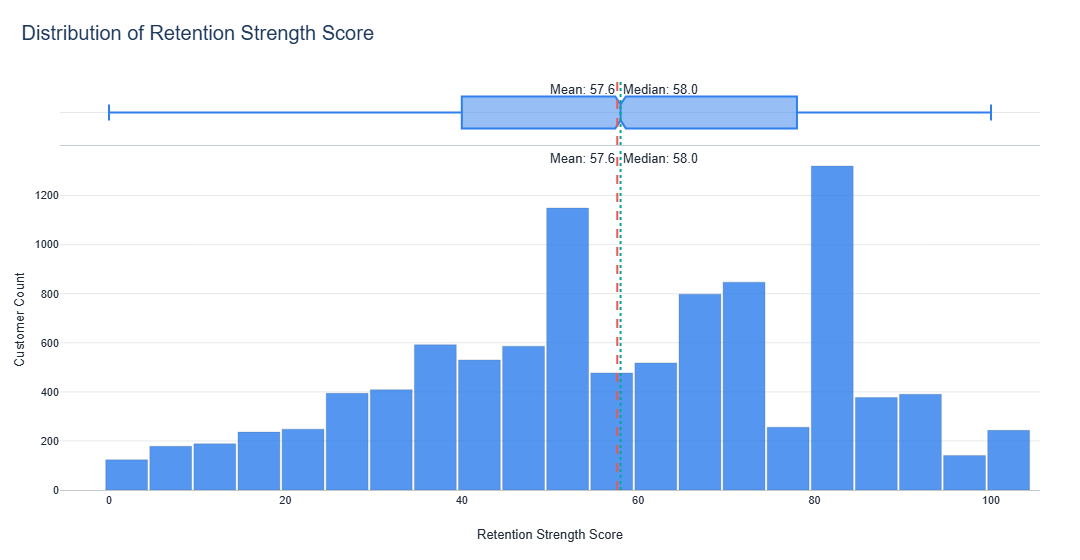

,Metric,Value
0,Minimum Retention Strength Score,0.00
1,Maximum Retention Strength Score,100.00
2,Average Retention Strength Score,57.63
3,Median Retention Strength Score,58.00
4,Score Standard Deviation,23.75


In [64]:
# Step 9G: Seaborn + Plotly Interactive Retention Strength Score Distribution
# Visualization stack: Seaborn + Plotly only
# No direct Matplotlib charting logic used

# -----------------------------
# 1. Retention Score Summary
# -----------------------------

retention_score_distribution_summary = pd.DataFrame({
    "Metric": [
        "Minimum Retention Strength Score",
        "Maximum Retention Strength Score",
        "Average Retention Strength Score",
        "Median Retention Strength Score",
        "Score Standard Deviation"
    ],
    "Value": [
        df["Retention_Strength_Score"].min(),
        df["Retention_Strength_Score"].max(),
        df["Retention_Strength_Score"].mean(),
        df["Retention_Strength_Score"].median(),
        df["Retention_Strength_Score"].std()
    ]
})

retention_score_distribution_summary["Value"] = (
    retention_score_distribution_summary["Value"].round(2)
)

score_mean = df["Retention_Strength_Score"].mean()
score_median = df["Retention_Strength_Score"].median()

# -----------------------------
# 2. Seaborn Premium Palette
# -----------------------------

score_palette = sns.color_palette(
    [
        BRAND_COLORS["blue"],
        BRAND_COLORS["sky"],
        BRAND_COLORS["teal"]
    ]
).as_hex()

# -----------------------------
# 3. Plotly Interactive Histogram
# -----------------------------

retention_score_distribution_fig = px.histogram(
    df,
    x="Retention_Strength_Score",
    nbins=35,
    marginal="box",
    opacity=0.82,
    color_discrete_sequence=[score_palette[0]],
    labels={
        "Retention_Strength_Score": "Retention Strength Score"
    },
    title="Distribution of Retention Strength Score"
)

retention_score_distribution_fig.update_traces(
    marker=dict(
        line=dict(
            color="rgba(31, 58, 95, 0.25)",
            width=1
        )
    ),
    hovertemplate=(
        "Retention Score Range: %{x}<br>"
        "Customer Count: %{y:,.0f}"
        "<extra></extra>"
    )
)

# Mean reference line
retention_score_distribution_fig.add_vline(
    x=score_mean,
    line_dash="dash",
    line_color=BRAND_COLORS["coral"],
    annotation_text=f"Mean: {score_mean:.1f}",
    annotation_position="top left"
)

# Median reference line
retention_score_distribution_fig.add_vline(
    x=score_median,
    line_dash="dot",
    line_color=BRAND_COLORS["teal"],
    annotation_text=f"Median: {score_median:.1f}",
    annotation_position="top right"
)

retention_score_distribution_fig = apply_premium_plotly_layout(
    retention_score_distribution_fig,
    title="Distribution of Retention Strength Score",
    x_title="Retention Strength Score",
    y_title="Customer Count",
    height=560,
    showlegend=False
)

retention_score_distribution_fig.update_layout(
    bargap=0.05
)

retention_score_distribution_fig.show()

retention_score_distribution_summary

### Seaborn Chart — Churn by Retention Strength Tier

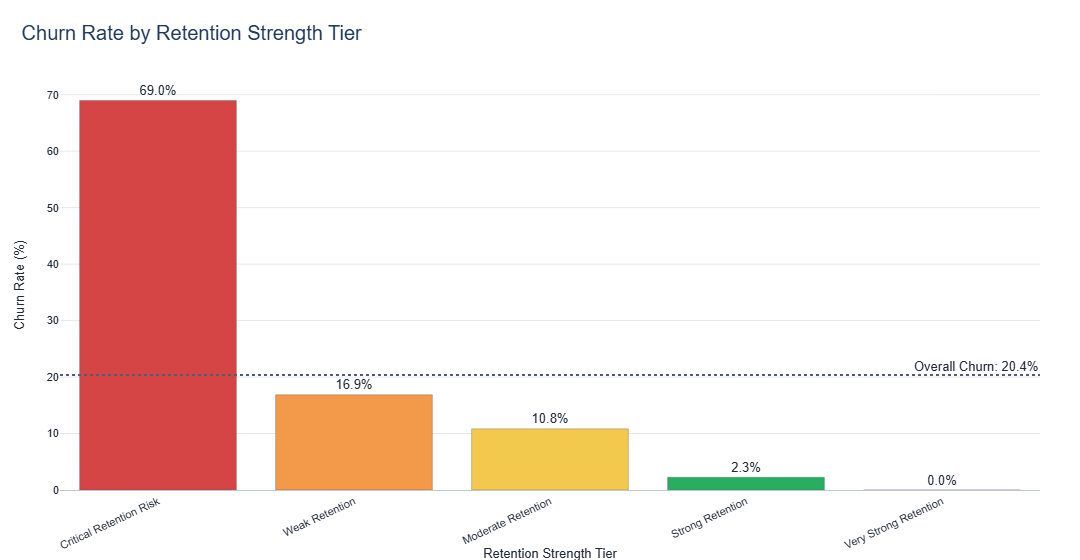

,Retention_Strength_Tier,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Churn_Rate,Retention_Rate
0,Critical Retention Risk,1776,1225,551,20.92,40.69,68.98,31.02
4,Weak Retention,2857,482,2375,45.95,52.81,16.87,83.13
1,Moderate Retention,2640,286,2354,65.61,70.54,10.83,89.17
2,Strong Retention,1953,44,1909,82.30,82.62,2.25,97.75
3,Very Strong Retention,774,0,774,95.49,95.23,0.00,100.00


In [66]:
# Step 9H: Premium Plotly Chart - Churn by Retention Strength Tier

retention_tier_churn = (
    df.groupby("Retention_Strength_Tier")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean")
    )
    .reset_index()
)

retention_tier_churn["Churn_Rate"] = (
    retention_tier_churn["Churned_Customers"] /
    retention_tier_churn["Customer_Count"] * 100
).round(2)

retention_tier_churn["Retention_Rate"] = (
    retention_tier_churn["Retained_Customers"] /
    retention_tier_churn["Customer_Count"] * 100
).round(2)

for col in ["Avg_Retention_Strength_Score", "Avg_Relationship_Strength"]:
    retention_tier_churn[col] = retention_tier_churn[col].round(2)

retention_tier_churn = apply_categorical_order(
    retention_tier_churn,
    "Retention_Strength_Tier",
    RETENTION_TIER_ORDER
)

retention_tier_churn["Tier_Color"] = get_color_list(
    retention_tier_churn["Retention_Strength_Tier"],
    RETENTION_TIER_COLORS
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=retention_tier_churn["Retention_Strength_Tier"],
        y=retention_tier_churn["Churn_Rate"],
        text=retention_tier_churn["Churn_Rate"],
        marker=dict(
            color=retention_tier_churn["Tier_Color"],
            line=dict(color="rgba(31,58,95,0.25)", width=1)
        ),
        customdata=np.stack(
            [
                retention_tier_churn["Customer_Count"],
                retention_tier_churn["Churned_Customers"],
                retention_tier_churn["Retained_Customers"],
                retention_tier_churn["Retention_Rate"],
                retention_tier_churn["Avg_Retention_Strength_Score"],
                retention_tier_churn["Avg_Relationship_Strength"]
            ],
            axis=-1
        ),
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Churn Rate: %{y:.2f}%<br>"
            "Retention Rate: %{customdata[3]:.2f}%<br>"
            "Customers: %{customdata[0]:,.0f}<br>"
            "Churned: %{customdata[1]:,.0f}<br>"
            "Retained: %{customdata[2]:,.0f}<br>"
            "Avg Retention Score: %{customdata[4]:.2f}<br>"
            "Avg Relationship Strength: %{customdata[5]:.2f}"
            "<extra></extra>"
        )
    )
)

fig = add_bar_value_labels(
    fig,
    texttemplate="%{text:.1f}%",
    position="outside"
)

fig = apply_premium_plotly_layout(
    fig,
    title="Churn Rate by Retention Strength Tier",
    x_title="Retention Strength Tier",
    y_title="Churn Rate (%)",
    height=560,
    showlegend=False,
    x_tickangle=-25
)

fig.add_hline(
    y=df["Exited"].mean() * 100,
    line_dash="dot",
    line_color=BRAND_COLORS["slate"],
    annotation_text=f"Overall Churn: {df['Exited'].mean() * 100:.1f}%",
    annotation_position="top right"
)

fig.show()

retention_tier_churn.drop(columns=["Tier_Color"])

### Engagement Status vs Retention Strength Matrix

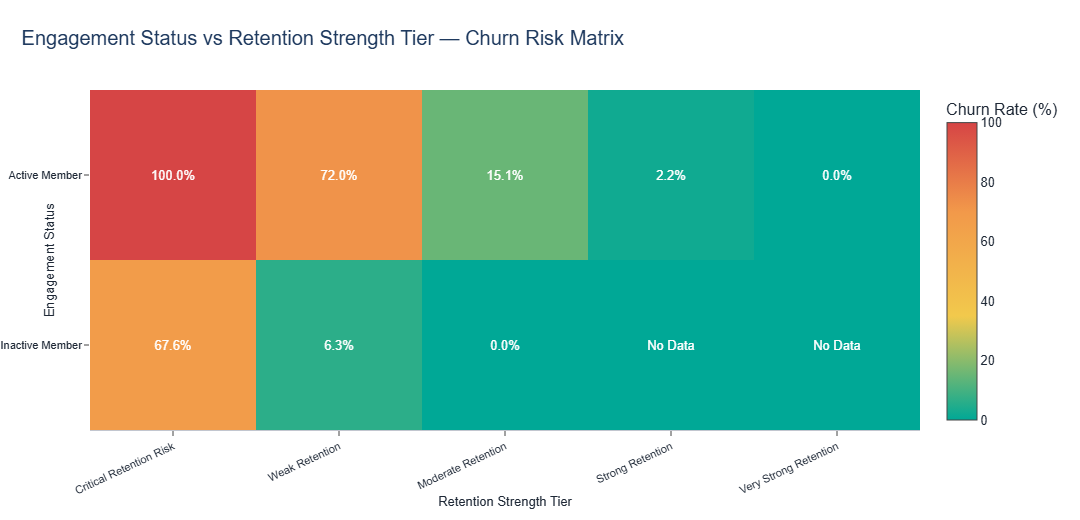

,Engagement_Status,Retention_Strength_Tier,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Avg_Balance,Churn_Rate,Retention_Rate
5,Inactive Member,Critical Retention Risk,1701,1150,551,20.59,39.96,1.24,"77,377.03",67.61,32.39
7,Inactive Member,Weak Retention,2399,152,2247,45.88,50.28,1.57,"73,082.50",6.34,93.66
6,Inactive Member,Moderate Retention,749,0,749,62.98,64.87,2.01,"89,561.19",0.00,100.00
0,Active Member,Critical Retention Risk,75,75,0,28.49,57.40,1.00,"56,099.98",100.00,0.00
4,Active Member,Weak Retention,458,330,128,46.30,66.07,1.15,"67,855.16",72.05,27.95
1,Active Member,Moderate Retention,1891,286,1605,66.65,72.78,1.33,"79,005.84",15.12,84.88
2,Active Member,Strong Retention,1953,44,1909,82.30,82.62,1.66,"69,709.13",2.25,97.75
3,Active Member,Very Strong Retention,774,0,774,95.49,95.23,2.01,"90,448.53",0.00,100.00


In [67]:
# Step 9I: Premium Plotly Matrix - Engagement Status vs Retention Strength Tier

# -----------------------------
# 1. Create Engagement vs Retention Strength Matrix
# -----------------------------

engagement_retention_matrix = (
    df.groupby(["Engagement_Status", "Retention_Strength_Tier"])
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

engagement_retention_matrix["Churn_Rate"] = (
    engagement_retention_matrix["Churned_Customers"] /
    engagement_retention_matrix["Customer_Count"] * 100
).round(2)

engagement_retention_matrix["Retention_Rate"] = (
    engagement_retention_matrix["Retained_Customers"] /
    engagement_retention_matrix["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products",
    "Avg_Balance"
]:
    engagement_retention_matrix[col] = engagement_retention_matrix[col].round(2)

# -----------------------------
# 2. Ensure Correct Category Order
# -----------------------------

engagement_retention_matrix["Engagement_Status"] = pd.Categorical(
    engagement_retention_matrix["Engagement_Status"],
    categories=ENGAGEMENT_ORDER,
    ordered=True
)

engagement_retention_matrix["Retention_Strength_Tier"] = pd.Categorical(
    engagement_retention_matrix["Retention_Strength_Tier"],
    categories=RETENTION_TIER_ORDER,
    ordered=True
)

engagement_retention_matrix = engagement_retention_matrix.sort_values(
    ["Engagement_Status", "Retention_Strength_Tier"]
)

# -----------------------------
# 3. Build Pivot Tables for Heatmap
# -----------------------------

engagement_churn_pivot = engagement_retention_matrix.pivot(
    index="Engagement_Status",
    columns="Retention_Strength_Tier",
    values="Churn_Rate"
).reindex(index=ENGAGEMENT_ORDER, columns=RETENTION_TIER_ORDER)

engagement_customer_pivot = engagement_retention_matrix.pivot(
    index="Engagement_Status",
    columns="Retention_Strength_Tier",
    values="Customer_Count"
).reindex(index=ENGAGEMENT_ORDER, columns=RETENTION_TIER_ORDER)

engagement_retention_pivot = engagement_retention_matrix.pivot(
    index="Engagement_Status",
    columns="Retention_Strength_Tier",
    values="Retention_Rate"
).reindex(index=ENGAGEMENT_ORDER, columns=RETENTION_TIER_ORDER)

# -----------------------------
# 4. Custom Data for Hover
# -----------------------------

customdata = np.stack(
    [
        engagement_customer_pivot.fillna(0).values,
        engagement_retention_pivot.fillna(0).values
    ],
    axis=-1
)

# -----------------------------
# 5. Interactive Plotly Heatmap
# -----------------------------

fig = go.Figure(
    data=go.Heatmap(
        z=engagement_churn_pivot.fillna(0).values,
        x=RETENTION_TIER_ORDER,
        y=ENGAGEMENT_ORDER,
        colorscale=[
            [0.00, BRAND_COLORS["teal"]],
            [0.35, BRAND_COLORS["amber"]],
            [0.70, BRAND_COLORS["orange"]],
            [1.00, BRAND_COLORS["red"]]
        ],
        text=np.where(
            engagement_churn_pivot.isna(),
            "No Data",
            engagement_churn_pivot.round(1).astype(str) + "%"
        ),
        texttemplate="%{text}",
        textfont=dict(size=13, color="white"),
        customdata=customdata,
        colorbar=dict(
            title="Churn Rate (%)"
        ),
        hovertemplate=(
            "<b>Engagement Status:</b> %{y}<br>"
            "<b>Retention Tier:</b> %{x}<br>"
            "<b>Churn Rate:</b> %{z:.2f}%<br>"
            "<b>Retention Rate:</b> %{customdata[1]:.2f}%<br>"
            "<b>Customer Count:</b> %{customdata[0]:,.0f}"
            "<extra></extra>"
        )
    )
)

fig = apply_premium_plotly_layout(
    fig,
    title="Engagement Status vs Retention Strength Tier — Churn Risk Matrix",
    x_title="Retention Strength Tier",
    y_title="Engagement Status",
    height=520,
    showlegend=False,
    x_tickangle=-25
)

fig.update_layout(
    margin=dict(l=90, r=60, t=90, b=90)
)

fig.show()

engagement_retention_matrix

### Product Depth vs Retention Strength Matrix

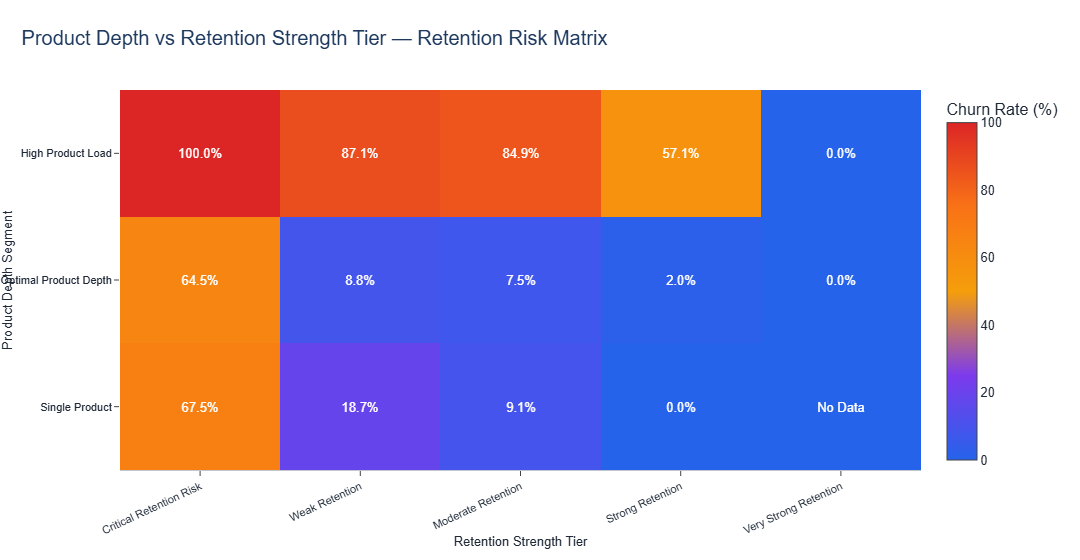

,Product_Depth_Segment,Retention_Strength_Tier,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Avg_Balance,Churn_Rate,Retention_Rate
10,Single Product,Critical Retention Risk,1480,999,481,19.69,40.28,1.00,"80,887.31",67.50,32.50
13,Single Product,Weak Retention,1530,286,1244,44.95,53.21,1.00,"104,916.01",18.69,81.31
11,Single Product,Moderate Retention,1364,124,1240,66.30,71.82,1.00,"94,246.01",9.09,90.91
12,Single Product,Strong Retention,710,0,710,81.67,80.87,1.00,"129,931.61",0.00,100.00
5,Optimal Product Depth,Critical Retention Risk,197,127,70,28.13,48.81,2.00,"47,447.01",64.47,35.53
9,Optimal Product Depth,Weak Retention,1226,108,1118,47.37,52.93,2.00,"29,968.91",8.81,91.19
6,Optimal Product Depth,Moderate Retention,1190,89,1101,64.90,69.60,2.00,"68,562.09",7.48,92.52
7,Optimal Product Depth,Strong Retention,1208,24,1184,82.75,84.01,2.00,"33,964.02",1.99,98.01
8,Optimal Product Depth,Very Strong Retention,769,0,769,95.48,95.40,2.00,"90,271.66",0.00,100.00
0,High Product Load,Critical Retention Risk,99,99,0,25.06,30.71,3.19,"68,338.83",100.00,0.00


In [68]:
# Step 9J Upgrade: Premium Plotly Matrix - Product Depth vs Retention Strength Tier

# -----------------------------
# 1. Create Product Depth vs Retention Strength Matrix
# -----------------------------

product_depth_retention_plot = (
    df.groupby(["Product_Depth_Segment", "Retention_Strength_Tier"])
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

product_depth_retention_plot["Churn_Rate"] = (
    product_depth_retention_plot["Churned_Customers"] /
    product_depth_retention_plot["Customer_Count"] * 100
).round(2)

product_depth_retention_plot["Retention_Rate"] = (
    product_depth_retention_plot["Retained_Customers"] /
    product_depth_retention_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products",
    "Avg_Balance"
]:
    product_depth_retention_plot[col] = product_depth_retention_plot[col].round(2)

# -----------------------------
# 2. Ensure Correct Category Order
# -----------------------------

product_depth_retention_plot["Product_Depth_Segment"] = pd.Categorical(
    product_depth_retention_plot["Product_Depth_Segment"],
    categories=PRODUCT_DEPTH_ORDER,
    ordered=True
)

product_depth_retention_plot["Retention_Strength_Tier"] = pd.Categorical(
    product_depth_retention_plot["Retention_Strength_Tier"],
    categories=RETENTION_TIER_ORDER,
    ordered=True
)

product_depth_retention_plot = product_depth_retention_plot.sort_values(
    ["Product_Depth_Segment", "Retention_Strength_Tier"]
)

# -----------------------------
# 3. Build Pivot Tables for Heatmap
# -----------------------------

product_depth_churn_pivot = product_depth_retention_plot.pivot(
    index="Product_Depth_Segment",
    columns="Retention_Strength_Tier",
    values="Churn_Rate"
).reindex(index=PRODUCT_DEPTH_ORDER, columns=RETENTION_TIER_ORDER)

product_depth_customer_pivot = product_depth_retention_plot.pivot(
    index="Product_Depth_Segment",
    columns="Retention_Strength_Tier",
    values="Customer_Count"
).reindex(index=PRODUCT_DEPTH_ORDER, columns=RETENTION_TIER_ORDER)

product_depth_retention_pivot = product_depth_retention_plot.pivot(
    index="Product_Depth_Segment",
    columns="Retention_Strength_Tier",
    values="Retention_Rate"
).reindex(index=PRODUCT_DEPTH_ORDER, columns=RETENTION_TIER_ORDER)

product_depth_avg_score_pivot = product_depth_retention_plot.pivot(
    index="Product_Depth_Segment",
    columns="Retention_Strength_Tier",
    values="Avg_Retention_Strength_Score"
).reindex(index=PRODUCT_DEPTH_ORDER, columns=RETENTION_TIER_ORDER)

# -----------------------------
# 4. Custom Data for Hover
# -----------------------------

customdata = np.stack(
    [
        product_depth_customer_pivot.fillna(0).values,
        product_depth_retention_pivot.fillna(0).values,
        product_depth_avg_score_pivot.fillna(0).values
    ],
    axis=-1
)

# -----------------------------
# 5. Interactive Plotly Heatmap
# -----------------------------

fig = go.Figure(
    data=go.Heatmap(
        z=product_depth_churn_pivot.fillna(0).values,
        x=RETENTION_TIER_ORDER,
        y=PRODUCT_DEPTH_ORDER,
        colorscale=[
            [0.00, "#2563EB"],   # Blue - low churn
            [0.25, "#7C3AED"],   # Purple
            [0.50, "#F59E0B"],   # Amber
            [0.75, "#F97316"],   # Orange
            [1.00, "#DC2626"]    # Red - high churn
        ],
        text=np.where(
            product_depth_churn_pivot.isna(),
            "No Data",
            product_depth_churn_pivot.round(1).astype(str) + "%"
        ),
        texttemplate="%{text}",
        textfont=dict(size=13, color="white"),
        customdata=customdata,
        colorbar=dict(
            title="Churn Rate (%)"
        ),
        hovertemplate=(
            "<b>Product Depth Segment:</b> %{y}<br>"
            "<b>Retention Tier:</b> %{x}<br>"
            "<b>Churn Rate:</b> %{z:.2f}%<br>"
            "<b>Retention Rate:</b> %{customdata[1]:.2f}%<br>"
            "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
            "<b>Avg Retention Score:</b> %{customdata[2]:.2f}"
            "<extra></extra>"
        )
    )
)

fig = apply_premium_plotly_layout(
    fig,
    title="Product Depth vs Retention Strength Tier — Retention Risk Matrix",
    x_title="Retention Strength Tier",
    y_title="Product Depth Segment",
    height=560,
    showlegend=False,
    x_tickangle=-25
)

fig.update_layout(
    margin=dict(l=120, r=60, t=90, b=90)
)

fig.show()

product_depth_retention_plot

### Customer Risk Segment Distribution

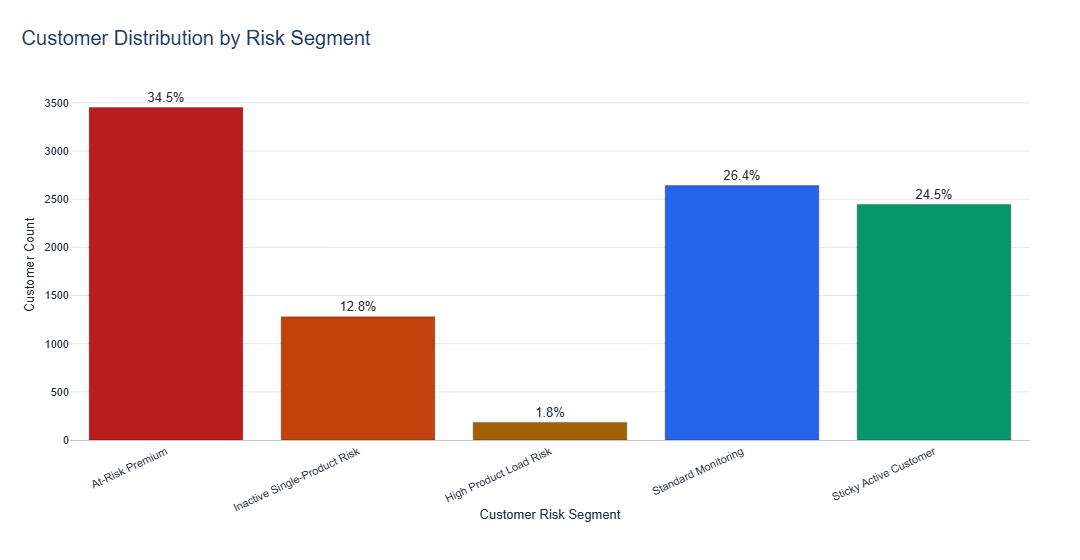

,Customer_Risk_Segment,Customer_Count,Customer_%
0,At-Risk Premium,3452,34.52
1,Inactive Single-Product Risk,1279,12.79
2,High Product Load Risk,182,1.82
3,Standard Monitoring,2641,26.41
4,Sticky Active Customer,2446,24.46


In [69]:
# Step 9K Upgrade: Premium Plotly Chart - Customer Risk Segment Distribution

# -----------------------------
# 1. Create Customer Risk Segment Distribution
# -----------------------------

customer_risk_distribution_plot = (
    df["Customer_Risk_Segment"]
    .value_counts()
    .reset_index()
)

customer_risk_distribution_plot.columns = [
    "Customer_Risk_Segment",
    "Customer_Count"
]

customer_risk_distribution_plot["Customer_%"] = (
    customer_risk_distribution_plot["Customer_Count"] / len(df) * 100
).round(2)

# -----------------------------
# 2. Safe Customer Risk Segment Order
# -----------------------------

customer_risk_order = [
    "At-Risk Premium",
    "Inactive Single-Product Risk",
    "High Product Load Risk",
    "Standard Monitoring",
    "Sticky Active Customer"
]

available_risk_order = [
    segment for segment in customer_risk_order
    if segment in customer_risk_distribution_plot["Customer_Risk_Segment"].unique()
]

remaining_risk_segments = [
    segment for segment in customer_risk_distribution_plot["Customer_Risk_Segment"].unique()
    if segment not in available_risk_order
]

final_risk_order = available_risk_order + remaining_risk_segments

customer_risk_distribution_plot["Customer_Risk_Segment"] = pd.Categorical(
    customer_risk_distribution_plot["Customer_Risk_Segment"],
    categories=final_risk_order,
    ordered=True
)

customer_risk_distribution_plot = customer_risk_distribution_plot.sort_values(
    "Customer_Risk_Segment"
).reset_index(drop=True)

# -----------------------------
# 3. Premium Different Color System
# -----------------------------

risk_segment_colors = {
    "At-Risk Premium": "#B91C1C",
    "Inactive Single-Product Risk": "#C2410C",
    "High Product Load Risk": "#A16207",
    "Standard Monitoring": "#2563EB",
    "Sticky Active Customer": "#059669"
}

customer_risk_distribution_plot["Segment_Color"] = (
    customer_risk_distribution_plot["Customer_Risk_Segment"]
    .astype(str)
    .map(risk_segment_colors)
    .fillna("#64748B")
)

# -----------------------------
# 4. Interactive Plotly Bar Chart
# -----------------------------

fig = px.bar(
    customer_risk_distribution_plot,
    x="Customer_Risk_Segment",
    y="Customer_Count",
    text="Customer_%",
    color="Customer_Risk_Segment",
    color_discrete_map=risk_segment_colors,
    custom_data=[
        "Customer_Count",
        "Customer_%"
    ]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    marker_line_color="rgba(15, 23, 42, 0.25)",
    marker_line_width=1.2,
    hovertemplate=(
        "<b>Customer Risk Segment:</b> %{x}<br>"
        "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
        "<b>Customer Share:</b> %{customdata[1]:.2f}%"
        "<extra></extra>"
    )
)

fig = apply_premium_plotly_layout(
    fig,
    title="Customer Distribution by Risk Segment",
    x_title="Customer Risk Segment",
    y_title="Customer Count",
    height=560,
    showlegend=False,
    x_tickangle=-25
)

fig.update_layout(
    margin=dict(l=70, r=50, t=90, b=120)
)

fig.show()

customer_risk_distribution_plot.drop(columns=["Segment_Color"])

### Churn Rate by Customer Risk Segment

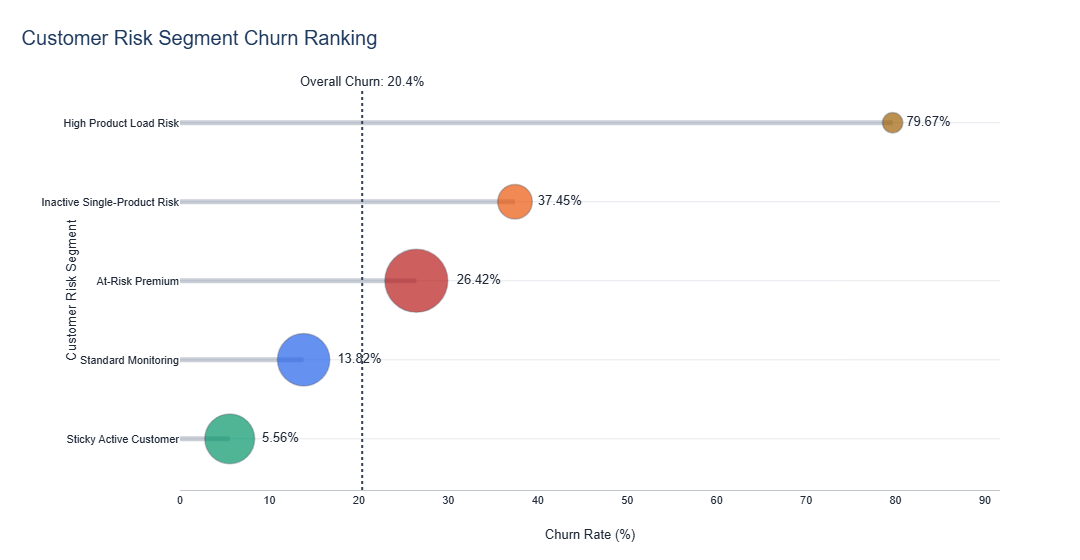

,Customer_Risk_Segment,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Avg_Balance,Churn_Rate,Retention_Rate
0,Sticky Active Customer,2446,136,2310,83.75,86.31,2.00,"51,852.94",5.56,94.44
1,Standard Monitoring,2641,365,2276,53.43,62.16,1.50,"53,801.33",13.82,86.18
2,At-Risk Premium,3452,912,2540,55.39,60.52,1.33,"113,780.60",26.42,73.58
3,Inactive Single-Product Risk,1279,479,800,24.27,40.55,1.00,"72,971.53",37.45,62.55
4,High Product Load Risk,182,145,37,44.45,46.07,3.16,"54,044.33",79.67,20.33


In [70]:
# Step 9L Upgrade: Premium Plotly Lollipop/Bubble Chart - Churn Risk Ranking by Customer Risk Segment

# -----------------------------
# 1. Create Risk Segment Churn Analysis
# -----------------------------

risk_segment_churn_plot = (
    df.groupby("Customer_Risk_Segment")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

risk_segment_churn_plot["Churn_Rate"] = (
    risk_segment_churn_plot["Churned_Customers"] /
    risk_segment_churn_plot["Customer_Count"] * 100
).round(2)

risk_segment_churn_plot["Retention_Rate"] = (
    risk_segment_churn_plot["Retained_Customers"] /
    risk_segment_churn_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products",
    "Avg_Balance"
]:
    risk_segment_churn_plot[col] = risk_segment_churn_plot[col].round(2)

# -----------------------------
# 2. Sort by Churn Risk Ranking
# -----------------------------

risk_segment_churn_plot = risk_segment_churn_plot.sort_values(
    "Churn_Rate",
    ascending=True
).reset_index(drop=True)

overall_churn_rate = round(df["Exited"].mean() * 100, 2)

# -----------------------------
# 3. Premium Color System
# -----------------------------

risk_segment_colors = {
    "At-Risk Premium": "#B91C1C",
    "Inactive Single-Product Risk": "#EA580C",
    "High Product Load Risk": "#A16207",
    "Standard Monitoring": "#2563EB",
    "Sticky Active Customer": "#059669"
}

risk_segment_churn_plot["Segment_Color"] = (
    risk_segment_churn_plot["Customer_Risk_Segment"]
    .map(risk_segment_colors)
    .fillna("#64748B")
)

# Bubble size based on customer count
risk_segment_churn_plot["Bubble_Size"] = (
    risk_segment_churn_plot["Customer_Count"] /
    risk_segment_churn_plot["Customer_Count"].max() * 45
) + 18

# -----------------------------
# 4. Create Premium Lollipop Chart
# -----------------------------

fig = go.Figure()

# Horizontal lollipop lines
for _, row in risk_segment_churn_plot.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[0, row["Churn_Rate"]],
            y=[row["Customer_Risk_Segment"], row["Customer_Risk_Segment"]],
            mode="lines",
            line=dict(
                color="rgba(100, 116, 139, 0.35)",
                width=5
            ),
            hoverinfo="skip",
            showlegend=False
        )
    )

# Bubble markers
fig.add_trace(
    go.Scatter(
        x=risk_segment_churn_plot["Churn_Rate"],
        y=risk_segment_churn_plot["Customer_Risk_Segment"],
        mode="markers+text",
        text=risk_segment_churn_plot["Churn_Rate"].astype(str) + "%",
        textposition="middle right",
        marker=dict(
            size=risk_segment_churn_plot["Bubble_Size"],
            color=risk_segment_churn_plot["Segment_Color"],
            line=dict(
                color="rgba(15, 23, 42, 0.35)",
                width=1.5
            )
        ),
        customdata=risk_segment_churn_plot[
            [
                "Customer_Count",
                "Churned_Customers",
                "Retained_Customers",
                "Retention_Rate",
                "Avg_Retention_Strength_Score",
                "Avg_Relationship_Strength",
                "Avg_Num_Products",
                "Avg_Balance"
            ]
        ],
        hovertemplate=(
            "<b>Customer Risk Segment:</b> %{y}<br>"
            "<b>Churn Rate:</b> %{x:.2f}%<br>"
            "<b>Retention Rate:</b> %{customdata[3]:.2f}%<br>"
            "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
            "<b>Churned Customers:</b> %{customdata[1]:,.0f}<br>"
            "<b>Retained Customers:</b> %{customdata[2]:,.0f}<br>"
            "<b>Avg Retention Score:</b> %{customdata[4]:.2f}<br>"
            "<b>Avg Relationship Strength:</b> %{customdata[5]:.2f}<br>"
            "<b>Avg Products:</b> %{customdata[6]:.2f}<br>"
            "<b>Avg Balance:</b> %{customdata[7]:,.2f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Overall churn reference line
fig.add_vline(
    x=overall_churn_rate,
    line_dash="dot",
    line_color="#334155",
    annotation_text=f"Overall Churn: {overall_churn_rate:.1f}%",
    annotation_position="top"
)

fig = apply_premium_plotly_layout(
    fig,
    title="Customer Risk Segment Churn Ranking",
    x_title="Churn Rate (%)",
    y_title="Customer Risk Segment",
    height=560,
    showlegend=False
)

fig.update_layout(
    margin=dict(l=180, r=80, t=90, b=70),
    xaxis=dict(
        range=[0, max(risk_segment_churn_plot["Churn_Rate"].max() + 12, overall_churn_rate + 12)]
    )
)

fig.show()

risk_segment_churn_plot.drop(columns=["Segment_Color", "Bubble_Size"])

### Donut Pie Chart — Customer Risk Segment Mix

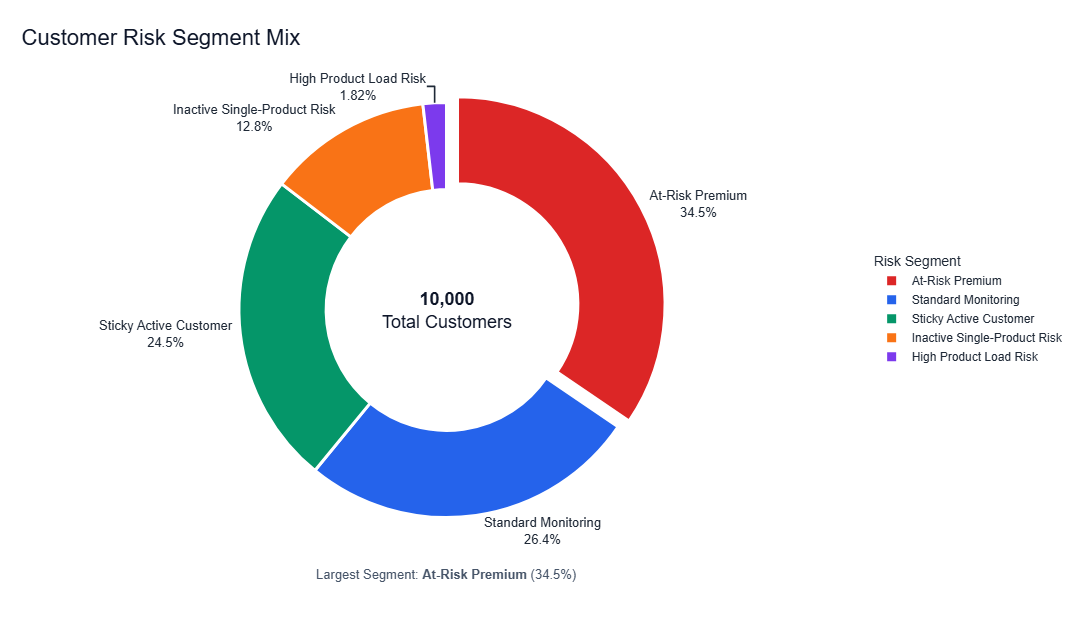

,Customer_Risk_Segment,Customer_Count,Customer_%
0,At-Risk Premium,3452,34.52
1,Standard Monitoring,2641,26.41
2,Sticky Active Customer,2446,24.46
3,Inactive Single-Product Risk,1279,12.79
4,High Product Load Risk,182,1.82


In [71]:
# Step 9M Upgrade: Premium Plotly Donut Chart - Customer Risk Segment Mix

# -----------------------------
# 1. Create Customer Risk Segment Distribution
# -----------------------------

customer_risk_distribution_plot = (
    df["Customer_Risk_Segment"]
    .value_counts()
    .reset_index()
)

customer_risk_distribution_plot.columns = [
    "Customer_Risk_Segment",
    "Customer_Count"
]

customer_risk_distribution_plot["Customer_%"] = (
    customer_risk_distribution_plot["Customer_Count"] / len(df) * 100
).round(2)

# -----------------------------
# 2. Safe Risk Segment Order
# -----------------------------

customer_risk_order = [
    "At-Risk Premium",
    "Standard Monitoring",
    "Sticky Active Customer",
    "Inactive Single-Product Risk",
    "High Product Load Risk"
]

available_risk_order = [
    segment for segment in customer_risk_order
    if segment in customer_risk_distribution_plot["Customer_Risk_Segment"].unique()
]

remaining_risk_segments = [
    segment for segment in customer_risk_distribution_plot["Customer_Risk_Segment"].unique()
    if segment not in available_risk_order
]

final_risk_order = available_risk_order + remaining_risk_segments

customer_risk_distribution_plot["Customer_Risk_Segment"] = pd.Categorical(
    customer_risk_distribution_plot["Customer_Risk_Segment"],
    categories=final_risk_order,
    ordered=True
)

customer_risk_distribution_plot = customer_risk_distribution_plot.sort_values(
    "Customer_Risk_Segment"
).reset_index(drop=True)

# -----------------------------
# 3. Premium Pie Color System
# -----------------------------

risk_segment_colors = {
    "At-Risk Premium": "#DC2626",
    "Standard Monitoring": "#2563EB",
    "Sticky Active Customer": "#059669",
    "Inactive Single-Product Risk": "#F97316",
    "High Product Load Risk": "#7C3AED"
}

customer_risk_distribution_plot["Segment_Color"] = (
    customer_risk_distribution_plot["Customer_Risk_Segment"]
    .astype(str)
    .map(risk_segment_colors)
    .fillna("#64748B")
)

largest_segment = customer_risk_distribution_plot.sort_values(
    "Customer_Count",
    ascending=False
).iloc[0]

# -----------------------------
# 4. Premium Donut Pie Chart
# -----------------------------

fig = go.Figure(
    data=[
        go.Pie(
            labels=customer_risk_distribution_plot["Customer_Risk_Segment"],
            values=customer_risk_distribution_plot["Customer_Count"],
            hole=0.58,
            sort=False,
            direction="clockwise",
            marker=dict(
                colors=customer_risk_distribution_plot["Segment_Color"],
                line=dict(
                    color="white",
                    width=3
                )
            ),
            textinfo="label+percent",
            textposition="outside",
            pull=[
                0.06 if segment == largest_segment["Customer_Risk_Segment"] else 0
                for segment in customer_risk_distribution_plot["Customer_Risk_Segment"]
            ],
            customdata=customer_risk_distribution_plot[
                [
                    "Customer_Count",
                    "Customer_%"
                ]
            ],
            hovertemplate=(
                "<b>Customer Risk Segment:</b> %{label}<br>"
                "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
                "<b>Customer Share:</b> %{customdata[1]:.2f}%"
                "<extra></extra>"
            )
        )
    ]
)

fig.update_layout(
    title=dict(
        text="Customer Risk Segment Mix",
        x=0.02,
        xanchor="left",
        font=dict(
            size=22,
            color="#0F172A",
            family="Arial"
        )
    ),
    annotations=[
        dict(
            text=(
                f"<b>{len(df):,}</b><br>"
                "Total Customers"
            ),
            x=0.5,
            y=0.5,
            font=dict(
                size=18,
                color="#0F172A"
            ),
            showarrow=False
        ),
        dict(
            text=(
                f"Largest Segment: <b>{largest_segment['Customer_Risk_Segment']}</b> "
                f"({largest_segment['Customer_%']:.1f}%)"
            ),
            x=0.5,
            y=-0.12,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(
                size=13,
                color="#475569"
            )
        )
    ],
    legend=dict(
        title="Risk Segment",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.05,
        font=dict(size=12)
    ),
    height=620,
    margin=dict(l=60, r=220, t=90, b=90),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()

customer_risk_distribution_plot.drop(columns=["Segment_Color"])

### Plotly Grouped Bar Chart - High Value Customer Status and Engagement Churn

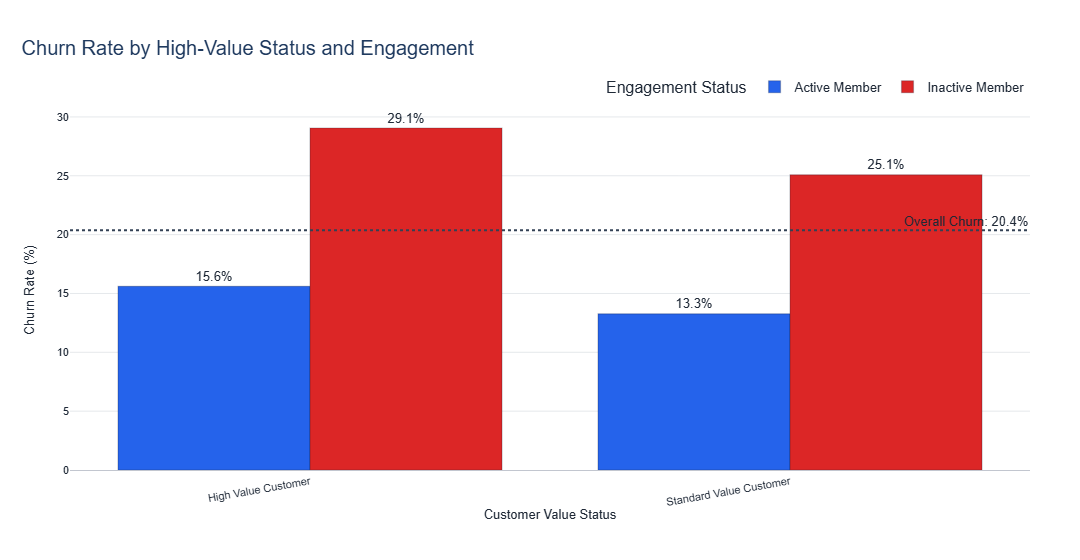

,High_Value_Customer_Status,Engagement_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Balance,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Churn_Rate,Retention_Rate
0,High Value Customer,Active Member,2197,343,1854,"107,507.50",80.09,81.47,1.47,15.61,84.39
1,High Value Customer,Inactive Member,2154,626,1528,"108,144.37",45.15,51.63,1.47,29.06,70.94
2,Standard Value Customer,Active Member,2954,392,2562,"52,349.46",70.43,77.28,1.58,13.27,86.73
3,Standard Value Customer,Inactive Member,2695,676,2019,"52,349.40",35.25,46.74,1.57,25.08,74.92


In [72]:
# Step 9N Upgrade: Premium Plotly Chart - High Value Customer Status and Engagement Churn

# -----------------------------
# 1. Create High-Value + Engagement Churn Analysis
# -----------------------------

high_balance_engagement_plot = (
    df.groupby(["High_Value_Customer_Status", "Engagement_Status"])
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Balance=("Balance", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

high_balance_engagement_plot["Churn_Rate"] = (
    high_balance_engagement_plot["Churned_Customers"] /
    high_balance_engagement_plot["Customer_Count"] * 100
).round(2)

high_balance_engagement_plot["Retention_Rate"] = (
    high_balance_engagement_plot["Retained_Customers"] /
    high_balance_engagement_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Balance",
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products"
]:
    high_balance_engagement_plot[col] = high_balance_engagement_plot[col].round(2)

# -----------------------------
# 2. Safe Ordering
# -----------------------------

value_status_order = [
    "High Value Customer",
    "Standard Value Customer"
]

engagement_order = [
    "Active Member",
    "Inactive Member"
]

available_value_order = [
    status for status in value_status_order
    if status in high_balance_engagement_plot["High_Value_Customer_Status"].unique()
]

available_engagement_order = [
    status for status in engagement_order
    if status in high_balance_engagement_plot["Engagement_Status"].unique()
]

high_balance_engagement_plot["High_Value_Customer_Status"] = pd.Categorical(
    high_balance_engagement_plot["High_Value_Customer_Status"],
    categories=available_value_order,
    ordered=True
)

high_balance_engagement_plot["Engagement_Status"] = pd.Categorical(
    high_balance_engagement_plot["Engagement_Status"],
    categories=available_engagement_order,
    ordered=True
)

high_balance_engagement_plot = high_balance_engagement_plot.sort_values(
    ["High_Value_Customer_Status", "Engagement_Status"]
).reset_index(drop=True)

overall_churn_rate = round(df["Exited"].mean() * 100, 2)

# -----------------------------
# 3. Premium Different Color System
# -----------------------------

engagement_colors = {
    "Active Member": "#2563EB",
    "Inactive Member": "#DC2626"
}

# -----------------------------
# 4. Interactive Grouped Bar Chart
# -----------------------------

fig = px.bar(
    high_balance_engagement_plot,
    x="High_Value_Customer_Status",
    y="Churn_Rate",
    color="Engagement_Status",
    barmode="group",
    text="Churn_Rate",
    color_discrete_map=engagement_colors,
    custom_data=[
        "Customer_Count",
        "Churned_Customers",
        "Retained_Customers",
        "Retention_Rate",
        "Avg_Balance",
        "Avg_Retention_Strength_Score",
        "Avg_Relationship_Strength",
        "Avg_Num_Products"
    ]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    marker_line_color="rgba(15, 23, 42, 0.25)",
    marker_line_width=1.2,
    hovertemplate=(
        "<b>Value Segment:</b> %{x}<br>"
        "<b>Engagement Status:</b> %{fullData.name}<br>"
        "<b>Churn Rate:</b> %{y:.2f}%<br>"
        "<b>Retention Rate:</b> %{customdata[3]:.2f}%<br>"
        "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
        "<b>Churned Customers:</b> %{customdata[1]:,.0f}<br>"
        "<b>Retained Customers:</b> %{customdata[2]:,.0f}<br>"
        "<b>Avg Balance:</b> %{customdata[4]:,.2f}<br>"
        "<b>Avg Retention Score:</b> %{customdata[5]:.2f}<br>"
        "<b>Avg Relationship Strength:</b> %{customdata[6]:.2f}<br>"
        "<b>Avg Products:</b> %{customdata[7]:.2f}"
        "<extra></extra>"
    )
)

fig.add_hline(
    y=overall_churn_rate,
    line_dash="dot",
    line_color="#334155",
    annotation_text=f"Overall Churn: {overall_churn_rate:.1f}%",
    annotation_position="top right"
)

fig = apply_premium_plotly_layout(
    fig,
    title="Churn Rate by High-Value Status and Engagement",
    x_title="Customer Value Status",
    y_title="Churn Rate (%)",
    height=560,
    showlegend=True,
    x_tickangle=-10
)

fig.update_layout(
    legend=dict(
        title="Engagement Status",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=70, r=50, t=110, b=90)
)

fig.show()

high_balance_engagement_plot

### Salary-Balance Mismatch Churn — Horizontal Bullet Chart

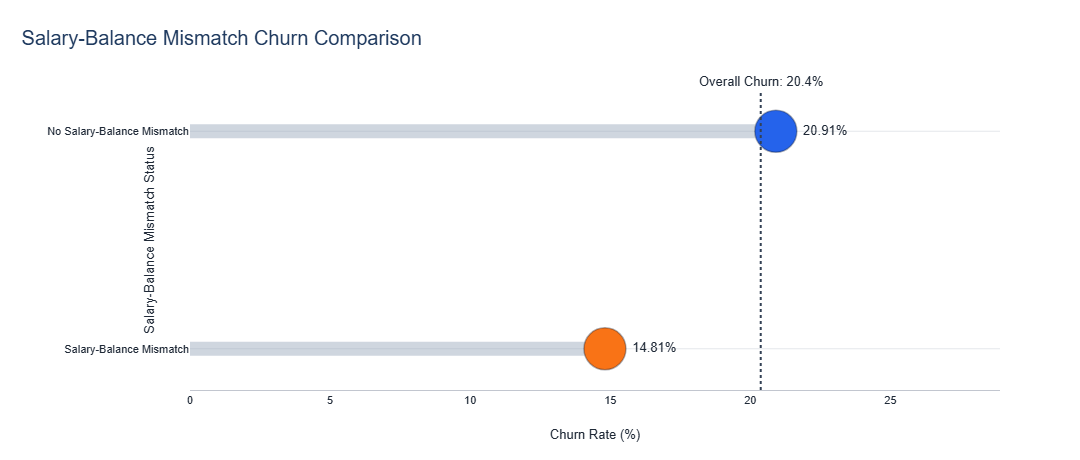

,Salary_Balance_Mismatch_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Balance,Avg_Estimated_Salary,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Churn_Rate,Retention_Rate
0,Salary-Balance Mismatch,891,132,759,0.00,"174,553.97",65.01,58.74,1.80,14.81,85.19
1,No Salary-Balance Mismatch,9109,1905,7204,"83,967.38","92,806.54",56.91,65.00,1.50,20.91,79.09


In [73]:
# Step 9O Upgrade: Premium Plotly Bullet Chart - Salary-Balance Mismatch Churn Comparison

# -----------------------------
# 1. Create Salary-Balance Mismatch Churn Analysis
# -----------------------------

salary_balance_mismatch_plot = (
    df.groupby("Salary_Balance_Mismatch_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Balance=("Balance", "mean"),
        Avg_Estimated_Salary=("EstimatedSalary", "mean"),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

salary_balance_mismatch_plot["Churn_Rate"] = (
    salary_balance_mismatch_plot["Churned_Customers"] /
    salary_balance_mismatch_plot["Customer_Count"] * 100
).round(2)

salary_balance_mismatch_plot["Retention_Rate"] = (
    salary_balance_mismatch_plot["Retained_Customers"] /
    salary_balance_mismatch_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Balance",
    "Avg_Estimated_Salary",
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products"
]:
    salary_balance_mismatch_plot[col] = salary_balance_mismatch_plot[col].round(2)

# -----------------------------
# 2. Safe Ordering
# -----------------------------

mismatch_order = [
    "Salary-Balance Mismatch",
    "No Salary-Balance Mismatch"
]

available_mismatch_order = [
    status for status in mismatch_order
    if status in salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"].unique()
]

remaining_mismatch_status = [
    status for status in salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"].unique()
    if status not in available_mismatch_order
]

final_mismatch_order = available_mismatch_order + remaining_mismatch_status

salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"] = pd.Categorical(
    salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"],
    categories=final_mismatch_order,
    ordered=True
)

salary_balance_mismatch_plot = salary_balance_mismatch_plot.sort_values(
    "Salary_Balance_Mismatch_Status",
    ascending=True
).reset_index(drop=True)

overall_churn_rate = round(df["Exited"].mean() * 100, 2)

# -----------------------------
# 3. Premium Color System
# -----------------------------

mismatch_colors = {
    "Salary-Balance Mismatch": "#F97316",
    "No Salary-Balance Mismatch": "#2563EB"
}

salary_balance_mismatch_plot["Status_Color"] = (
    salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"]
    .astype(str)
    .map(mismatch_colors)
    .fillna("#64748B")
)

# -----------------------------
# 4. Premium Horizontal Bullet / Lollipop Chart
# -----------------------------

fig = go.Figure()

for _, row in salary_balance_mismatch_plot.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[0, row["Churn_Rate"]],
            y=[row["Salary_Balance_Mismatch_Status"], row["Salary_Balance_Mismatch_Status"]],
            mode="lines",
            line=dict(
                color="rgba(148, 163, 184, 0.45)",
                width=14
            ),
            hoverinfo="skip",
            showlegend=False
        )
    )

fig.add_trace(
    go.Scatter(
        x=salary_balance_mismatch_plot["Churn_Rate"],
        y=salary_balance_mismatch_plot["Salary_Balance_Mismatch_Status"],
        mode="markers+text",
        text=salary_balance_mismatch_plot["Churn_Rate"].astype(str) + "%",
        textposition="middle right",
        marker=dict(
            size=42,
            color=salary_balance_mismatch_plot["Status_Color"],
            line=dict(
                color="rgba(15, 23, 42, 0.35)",
                width=1.5
            )
        ),
        customdata=salary_balance_mismatch_plot[
            [
                "Customer_Count",
                "Churned_Customers",
                "Retained_Customers",
                "Retention_Rate",
                "Avg_Balance",
                "Avg_Estimated_Salary",
                "Avg_Retention_Strength_Score",
                "Avg_Relationship_Strength",
                "Avg_Num_Products"
            ]
        ],
        hovertemplate=(
            "<b>Mismatch Status:</b> %{y}<br>"
            "<b>Churn Rate:</b> %{x:.2f}%<br>"
            "<b>Retention Rate:</b> %{customdata[3]:.2f}%<br>"
            "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
            "<b>Churned Customers:</b> %{customdata[1]:,.0f}<br>"
            "<b>Retained Customers:</b> %{customdata[2]:,.0f}<br>"
            "<b>Avg Balance:</b> %{customdata[4]:,.2f}<br>"
            "<b>Avg Estimated Salary:</b> %{customdata[5]:,.2f}<br>"
            "<b>Avg Retention Score:</b> %{customdata[6]:.2f}<br>"
            "<b>Avg Relationship Strength:</b> %{customdata[7]:.2f}<br>"
            "<b>Avg Products:</b> %{customdata[8]:.2f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

fig.add_vline(
    x=overall_churn_rate,
    line_dash="dot",
    line_color="#334155",
    annotation_text=f"Overall Churn: {overall_churn_rate:.1f}%",
    annotation_position="top"
)

fig = apply_premium_plotly_layout(
    fig,
    title="Salary-Balance Mismatch Churn Comparison",
    x_title="Churn Rate (%)",
    y_title="Salary-Balance Mismatch Status",
    height=460,
    showlegend=False
)

fig.update_layout(
    margin=dict(l=190, r=80, t=90, b=70),
    xaxis=dict(
        range=[0, max(salary_balance_mismatch_plot["Churn_Rate"].max() + 8, overall_churn_rate + 8)]
    )
)

fig.show()

salary_balance_mismatch_plot.drop(columns=["Status_Color"])

### Credit Card Ownership — Retention vs Churn 100% Stacked Chart

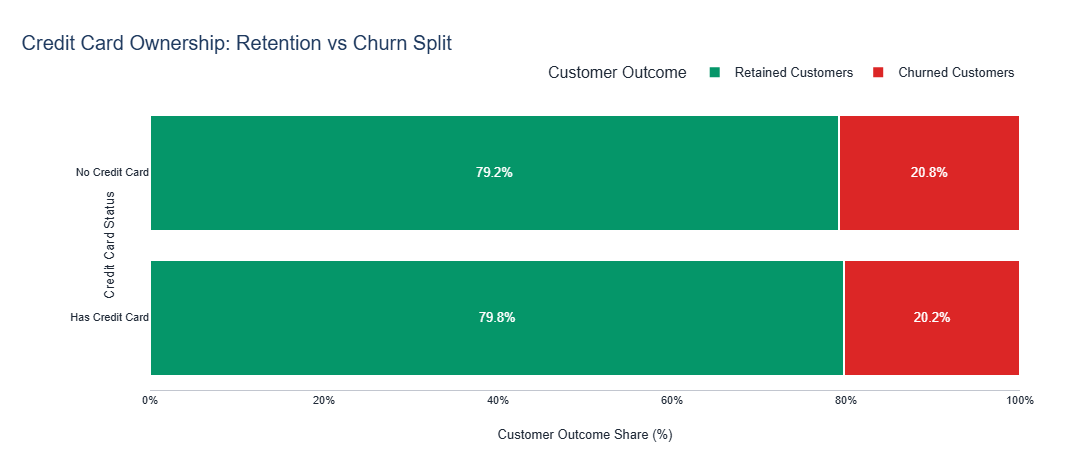

,Credit_Card_Status,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Num_Products,Avg_Balance,Churn_Rate,Retention_Rate
0,Has Credit Card,7055,1424,5631,61.64,67.29,1.53,"75,886.91",20.18,79.82
1,No Credit Card,2945,613,2332,48.01,57.62,1.53,"77,920.79",20.81,79.19


In [74]:
# Step 9P Upgrade: Premium Plotly 100% Stacked Chart - Credit Card Ownership Retention vs Churn

# -----------------------------
# 1. Create Credit Card Ownership Retention Analysis
# -----------------------------

credit_card_retention_plot = (
    df.groupby("Credit_Card_Status")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

credit_card_retention_plot["Churn_Rate"] = (
    credit_card_retention_plot["Churned_Customers"] /
    credit_card_retention_plot["Customer_Count"] * 100
).round(2)

credit_card_retention_plot["Retention_Rate"] = (
    credit_card_retention_plot["Retained_Customers"] /
    credit_card_retention_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Num_Products",
    "Avg_Balance"
]:
    credit_card_retention_plot[col] = credit_card_retention_plot[col].round(2)

# -----------------------------
# 2. Safe Ordering
# -----------------------------

credit_card_order = [
    "Has Credit Card",
    "No Credit Card"
]

available_credit_card_order = [
    status for status in credit_card_order
    if status in credit_card_retention_plot["Credit_Card_Status"].unique()
]

remaining_credit_card_status = [
    status for status in credit_card_retention_plot["Credit_Card_Status"].unique()
    if status not in available_credit_card_order
]

final_credit_card_order = available_credit_card_order + remaining_credit_card_status

credit_card_retention_plot["Credit_Card_Status"] = pd.Categorical(
    credit_card_retention_plot["Credit_Card_Status"],
    categories=final_credit_card_order,
    ordered=True
)

credit_card_retention_plot = credit_card_retention_plot.sort_values(
    "Credit_Card_Status"
).reset_index(drop=True)

# -----------------------------
# 3. Create 100% Stacked Data
# -----------------------------

credit_card_stacked_plot = credit_card_retention_plot.melt(
    id_vars=[
        "Credit_Card_Status",
        "Customer_Count",
        "Churned_Customers",
        "Retained_Customers",
        "Avg_Retention_Strength_Score",
        "Avg_Relationship_Strength",
        "Avg_Num_Products",
        "Avg_Balance"
    ],
    value_vars=[
        "Retention_Rate",
        "Churn_Rate"
    ],
    var_name="Customer_Outcome",
    value_name="Outcome_Rate"
)

credit_card_stacked_plot["Customer_Outcome"] = credit_card_stacked_plot["Customer_Outcome"].replace(
    {
        "Retention_Rate": "Retained Customers",
        "Churn_Rate": "Churned Customers"
    }
)

outcome_colors = {
    "Retained Customers": "#059669",
    "Churned Customers": "#DC2626"
}

# -----------------------------
# 4. Premium 100% Stacked Horizontal Chart
# -----------------------------

fig = px.bar(
    credit_card_stacked_plot,
    x="Outcome_Rate",
    y="Credit_Card_Status",
    color="Customer_Outcome",
    orientation="h",
    text="Outcome_Rate",
    color_discrete_map=outcome_colors,
    custom_data=[
        "Customer_Count",
        "Churned_Customers",
        "Retained_Customers",
        "Avg_Retention_Strength_Score",
        "Avg_Relationship_Strength",
        "Avg_Num_Products",
        "Avg_Balance"
    ]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="inside",
    insidetextanchor="middle",
    marker_line_color="white",
    marker_line_width=2,
    hovertemplate=(
        "<b>Credit Card Status:</b> %{y}<br>"
        "<b>Outcome:</b> %{fullData.name}<br>"
        "<b>Outcome Rate:</b> %{x:.2f}%<br>"
        "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
        "<b>Churned Customers:</b> %{customdata[1]:,.0f}<br>"
        "<b>Retained Customers:</b> %{customdata[2]:,.0f}<br>"
        "<b>Avg Retention Score:</b> %{customdata[3]:.2f}<br>"
        "<b>Avg Relationship Strength:</b> %{customdata[4]:.2f}<br>"
        "<b>Avg Products:</b> %{customdata[5]:.2f}<br>"
        "<b>Avg Balance:</b> %{customdata[6]:,.2f}"
        "<extra></extra>"
    )
)

fig = apply_premium_plotly_layout(
    fig,
    title="Credit Card Ownership: Retention vs Churn Split",
    x_title="Customer Outcome Share (%)",
    y_title="Credit Card Status",
    height=460,
    showlegend=True
)

fig.update_layout(
    barmode="stack",
    legend=dict(
        title="Customer Outcome",
        orientation="h",
        yanchor="bottom",
        y=1.04,
        xanchor="right",
        x=1
    ),
    margin=dict(l=150, r=60, t=100, b=70),
    xaxis=dict(
        range=[0, 100],
        ticksuffix="%"
    )
)

fig.show()

credit_card_retention_plot

### Plotly Line Chart - Churn Rate by Relationship Strength Tier

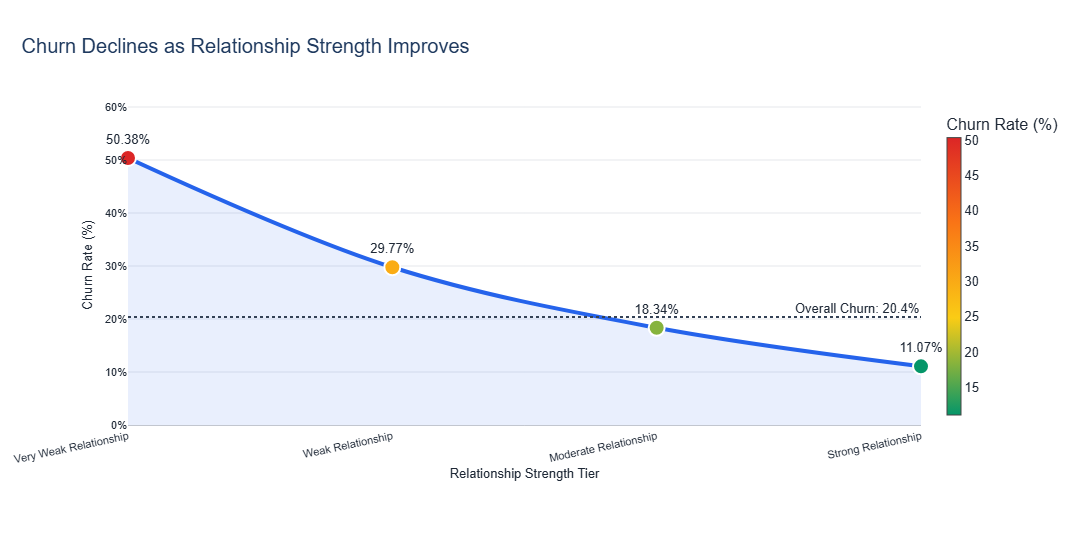

,Relationship_Strength_Tier,Customer_Count,Churned_Customers,Retained_Customers,Avg_Retention_Strength_Score,Avg_Relationship_Strength,Avg_Balance,Avg_Num_Products,Churn_Rate,Retention_Rate
0,Very Weak Relationship,262,132,130,17.39,22.12,"9,781.80",1.39,50.38,49.62
1,Weak Relationship,2869,854,2015,34.69,43.17,"67,479.35",1.41,29.77,70.23
2,Moderate Relationship,3996,733,3263,59.17,65.48,"78,214.53",1.51,18.34,81.66
3,Strong Relationship,2873,318,2555,82.06,88.11,"89,158.56",1.69,11.07,88.93


In [75]:
# Step 9Q Upgrade: Premium Plotly Line Chart - Churn Rate by Relationship Strength Tier

# -----------------------------
# 1. Create Relationship Strength Tier Churn Analysis
# -----------------------------

relationship_tier_churn_plot = (
    df.groupby("Relationship_Strength_Tier")
    .agg(
        Customer_Count=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Retained_Customers=("Exited", lambda x: (x == 0).sum()),
        Avg_Retention_Strength_Score=("Retention_Strength_Score", "mean"),
        Avg_Relationship_Strength=("Relationship_Strength_Index", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Num_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

relationship_tier_churn_plot["Churn_Rate"] = (
    relationship_tier_churn_plot["Churned_Customers"] /
    relationship_tier_churn_plot["Customer_Count"] * 100
).round(2)

relationship_tier_churn_plot["Retention_Rate"] = (
    relationship_tier_churn_plot["Retained_Customers"] /
    relationship_tier_churn_plot["Customer_Count"] * 100
).round(2)

for col in [
    "Avg_Retention_Strength_Score",
    "Avg_Relationship_Strength",
    "Avg_Balance",
    "Avg_Num_Products"
]:
    relationship_tier_churn_plot[col] = relationship_tier_churn_plot[col].round(2)

# -----------------------------
# 2. Safe Relationship Tier Ordering
# -----------------------------

relationship_tier_order = [
    "Very Weak Relationship",
    "Weak Relationship",
    "Moderate Relationship",
    "Strong Relationship"
]

available_relationship_order = [
    tier for tier in relationship_tier_order
    if tier in relationship_tier_churn_plot["Relationship_Strength_Tier"].unique()
]

remaining_relationship_tiers = [
    tier for tier in relationship_tier_churn_plot["Relationship_Strength_Tier"].unique()
    if tier not in available_relationship_order
]

final_relationship_order = available_relationship_order + remaining_relationship_tiers

relationship_tier_churn_plot["Relationship_Strength_Tier"] = pd.Categorical(
    relationship_tier_churn_plot["Relationship_Strength_Tier"],
    categories=final_relationship_order,
    ordered=True
)

relationship_tier_churn_plot = relationship_tier_churn_plot.sort_values(
    "Relationship_Strength_Tier"
).reset_index(drop=True)

overall_churn_rate = round(df["Exited"].mean() * 100, 2)

# -----------------------------
# 3. Premium Line Chart
# -----------------------------

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=relationship_tier_churn_plot["Relationship_Strength_Tier"],
        y=relationship_tier_churn_plot["Churn_Rate"],
        mode="lines+markers+text",
        text=relationship_tier_churn_plot["Churn_Rate"].astype(str) + "%",
        textposition="top center",
        line=dict(
            color="#2563EB",
            width=4,
            shape="spline"
        ),
        marker=dict(
            size=16,
            color=relationship_tier_churn_plot["Churn_Rate"],
            colorscale=[
                [0.00, "#059669"],
                [0.35, "#FACC15"],
                [0.70, "#F97316"],
                [1.00, "#DC2626"]
            ],
            showscale=True,
            colorbar=dict(
                title="Churn Rate (%)",
                thickness=14
            ),
            line=dict(
                color="white",
                width=2
            )
        ),
        fill="tozeroy",
        fillcolor="rgba(37, 99, 235, 0.10)",
        customdata=relationship_tier_churn_plot[
            [
                "Customer_Count",
                "Churned_Customers",
                "Retained_Customers",
                "Retention_Rate",
                "Avg_Retention_Strength_Score",
                "Avg_Relationship_Strength",
                "Avg_Balance",
                "Avg_Num_Products"
            ]
        ],
        hovertemplate=(
            "<b>Relationship Tier:</b> %{x}<br>"
            "<b>Churn Rate:</b> %{y:.2f}%<br>"
            "<b>Retention Rate:</b> %{customdata[3]:.2f}%<br>"
            "<b>Customer Count:</b> %{customdata[0]:,.0f}<br>"
            "<b>Churned Customers:</b> %{customdata[1]:,.0f}<br>"
            "<b>Retained Customers:</b> %{customdata[2]:,.0f}<br>"
            "<b>Avg Retention Score:</b> %{customdata[4]:.2f}<br>"
            "<b>Avg Relationship Strength:</b> %{customdata[5]:.2f}<br>"
            "<b>Avg Balance:</b> %{customdata[6]:,.2f}<br>"
            "<b>Avg Products:</b> %{customdata[7]:.2f}"
            "<extra></extra>"
        ),
        name="Churn Rate"
    )
)

fig.add_hline(
    y=overall_churn_rate,
    line_dash="dot",
    line_color="#334155",
    annotation_text=f"Overall Churn: {overall_churn_rate:.1f}%",
    annotation_position="top right"
)

fig = apply_premium_plotly_layout(
    fig,
    title="Churn Declines as Relationship Strength Improves",
    x_title="Relationship Strength Tier",
    y_title="Churn Rate (%)",
    height=560,
    showlegend=False,
    x_tickangle=-15
)

fig.update_layout(
    margin=dict(l=80, r=90, t=95, b=110),
    yaxis=dict(
        range=[
            0,
            max(relationship_tier_churn_plot["Churn_Rate"].max() + 8, overall_churn_rate + 8)
        ],
        ticksuffix="%"
    )
)

# Step 9Q Micro Polish Patch: Fix label clipping, spacing, and cleaner line readability

fig.update_traces(
    textposition="top center",
    cliponaxis=False
)

fig.update_layout(
    margin=dict(l=95, r=150, t=105, b=135),
    xaxis=dict(
        automargin=True,
        tickangle=-12
    ),
    yaxis=dict(
        automargin=True,
        ticksuffix="%",
        range=[
            0,
            max(
                relationship_tier_churn_plot["Churn_Rate"].max() + 10,
                overall_churn_rate + 10
            )
        ]
    )
)

fig.update_coloraxes(
    colorbar=dict(
        title="Churn Rate (%)",
        thickness=12,
        x=1.08
    )
)

fig.show()

relationship_tier_churn_plot

### Plotly Scatter Plot - Retention Strength vs Relationship Strength

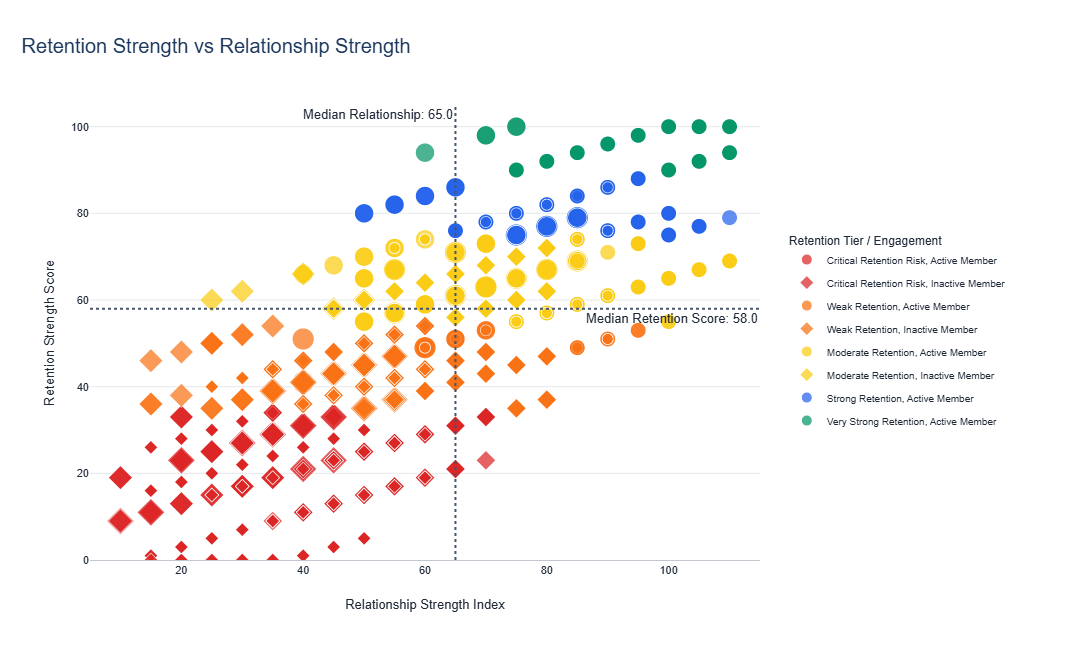

,CustomerId,Relationship_Strength_Index,Retention_Strength_Score,Retention_Strength_Tier,Engagement_Status,Product_Depth_Segment,Customer_Risk_Segment,NumOfProducts,Balance,Exited,Churn_Status,Bubble_Size
0,15619608,50,25.00,Critical Retention Risk,Inactive Member,Single Product,At-Risk Premium,1,"92,895.56",1,Churned Customer,7
1,15700212,50,15.00,Critical Retention Risk,Inactive Member,Optimal Product Depth,Standard Monitoring,2,0.00,1,Churned Customer,14
2,15617065,50,25.00,Critical Retention Risk,Inactive Member,Single Product,At-Risk Premium,1,"194,532.66",1,Churned Customer,7
3,15689786,35,9.00,Critical Retention Risk,Inactive Member,Single Product,At-Risk Premium,1,"169,743.83",1,Churned Customer,7
4,15648876,30,32.00,Critical Retention Risk,Inactive Member,Single Product,Inactive Single-Product Risk,1,0.00,0,Retained Customer,7
5,15792228,45,23.00,Critical Retention Risk,Inactive Member,Single Product,At-Risk Premium,1,"152,335.70",1,Churned Customer,7
6,15630725,40,21.00,Critical Retention Risk,Inactive Member,Single Product,At-Risk Premium,1,"92,786.66",1,Churned Customer,7
7,15646082,45,13.00,Critical Retention Risk,Inactive Member,Single Product,Inactive Single-Product Risk,1,"82,909.14",1,Churned Customer,7
8,15745080,35,34.00,Critical Retention Risk,Inactive Member,Single Product,Inactive Single-Product Risk,1,0.00,0,Retained Customer,7
9,15815095,65,21.00,Critical Retention Risk,Inactive Member,Optimal Product Depth,Standard Monitoring,2,"108,185.81",1,Churned Customer,14


In [76]:
# Step 9R Upgrade: Premium Plotly Scatter Plot - Retention Strength vs Relationship Strength

# -----------------------------
# 1. Create Scatter Dataset
# -----------------------------

relationship_strength_scatter_plot = df[
    [
        "CustomerId",
        "Relationship_Strength_Index",
        "Retention_Strength_Score",
        "Retention_Strength_Tier",
        "Engagement_Status",
        "Product_Depth_Segment",
        "Customer_Risk_Segment",
        "NumOfProducts",
        "Balance",
        "Exited"
    ]
].copy()

relationship_strength_scatter_plot["Churn_Status"] = relationship_strength_scatter_plot["Exited"].map(
    {
        0: "Retained Customer",
        1: "Churned Customer"
    }
)

relationship_strength_scatter_plot["Bubble_Size"] = (
    relationship_strength_scatter_plot["NumOfProducts"]
    .clip(lower=1, upper=4) * 7
)

# -----------------------------
# 2. Safe Tier Ordering + Premium Colors
# -----------------------------

retention_tier_order = [
    "Critical Retention Risk",
    "Weak Retention",
    "Moderate Retention",
    "Strong Retention",
    "Very Strong Retention"
]

retention_tier_colors = {
    "Critical Retention Risk": "#DC2626",
    "Weak Retention": "#F97316",
    "Moderate Retention": "#FACC15",
    "Strong Retention": "#2563EB",
    "Very Strong Retention": "#059669"
}

available_retention_order = [
    tier for tier in retention_tier_order
    if tier in relationship_strength_scatter_plot["Retention_Strength_Tier"].unique()
]

remaining_retention_tiers = [
    tier for tier in relationship_strength_scatter_plot["Retention_Strength_Tier"].unique()
    if tier not in available_retention_order
]

final_retention_order = available_retention_order + remaining_retention_tiers

relationship_strength_scatter_plot["Retention_Strength_Tier"] = pd.Categorical(
    relationship_strength_scatter_plot["Retention_Strength_Tier"],
    categories=final_retention_order,
    ordered=True
)

relationship_strength_scatter_plot = relationship_strength_scatter_plot.sort_values(
    "Retention_Strength_Tier"
).reset_index(drop=True)

# -----------------------------
# 3. Premium Scatter Plot
# -----------------------------

fig = px.scatter(
    relationship_strength_scatter_plot,
    x="Relationship_Strength_Index",
    y="Retention_Strength_Score",
    color="Retention_Strength_Tier",
    symbol="Engagement_Status",
    size="Bubble_Size",
    size_max=22,
    opacity=0.72,
    color_discrete_map=retention_tier_colors,
    category_orders={
        "Retention_Strength_Tier": final_retention_order,
        "Engagement_Status": ["Active Member", "Inactive Member"]
    },
    custom_data=[
        "CustomerId",
        "Retention_Strength_Tier",
        "Engagement_Status",
        "Product_Depth_Segment",
        "Customer_Risk_Segment",
        "NumOfProducts",
        "Balance",
        "Churn_Status"
    ]
)

fig.update_traces(
    marker=dict(
        line=dict(
            color="white",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>Customer ID:</b> %{customdata[0]}<br>"
        "<b>Relationship Strength:</b> %{x:.2f}<br>"
        "<b>Retention Strength Score:</b> %{y:.2f}<br>"
        "<b>Retention Tier:</b> %{customdata[1]}<br>"
        "<b>Engagement Status:</b> %{customdata[2]}<br>"
        "<b>Product Depth:</b> %{customdata[3]}<br>"
        "<b>Risk Segment:</b> %{customdata[4]}<br>"
        "<b>Number of Products:</b> %{customdata[5]}<br>"
        "<b>Balance:</b> %{customdata[6]:,.2f}<br>"
        "<b>Churn Status:</b> %{customdata[7]}"
        "<extra></extra>"
    )
)

# -----------------------------
# 4. Add Reference Lines
# -----------------------------

relationship_median = round(
    relationship_strength_scatter_plot["Relationship_Strength_Index"].median(),
    2
)

retention_median = round(
    relationship_strength_scatter_plot["Retention_Strength_Score"].median(),
    2
)

fig.add_vline(
    x=relationship_median,
    line_dash="dot",
    line_color="#475569",
    annotation_text=f"Median Relationship: {relationship_median}",
    annotation_position="top left"
)

fig.add_hline(
    y=retention_median,
    line_dash="dot",
    line_color="#475569",
    annotation_text=f"Median Retention Score: {retention_median}",
    annotation_position="bottom right"
)

# -----------------------------
# 5. Premium Layout
# -----------------------------

fig = apply_premium_plotly_layout(
    fig,
    title="Retention Strength vs Relationship Strength",
    x_title="Relationship Strength Index",
    y_title="Retention Strength Score",
    height=650,
    showlegend=True
)

fig.update_layout(
    legend=dict(
        title="Retention Tier / Engagement",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    ),
    margin=dict(l=80, r=260, t=95, b=80),
    xaxis=dict(
        range=[
            max(0, relationship_strength_scatter_plot["Relationship_Strength_Index"].min() - 5),
            relationship_strength_scatter_plot["Relationship_Strength_Index"].max() + 5
        ]
    ),
    yaxis=dict(
        range=[
            max(0, relationship_strength_scatter_plot["Retention_Strength_Score"].min() - 5),
            relationship_strength_scatter_plot["Retention_Strength_Score"].max() + 5
        ]
    )
)

# Step 9R Micro Polish Patch: Reduce clipping, improve legend spacing, and clean scatter readability

fig.update_traces(
    marker=dict(
        line=dict(
            color="white",
            width=0.7
        )
    ),
    selector=dict(mode="markers")
)

fig.update_layout(
    margin=dict(l=90, r=320, t=105, b=90),
    legend=dict(
        title="Retention Tier / Engagement",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.04,
        font=dict(size=10),
        itemsizing="constant",
        tracegroupgap=4
    ),
    xaxis=dict(
        automargin=True
    ),
    yaxis=dict(
        automargin=True
    )
)

fig.show()

relationship_strength_scatter_plot.head(10)

## Seaborn + Plotly Visual Insight Summary

This step summarizes the key business insights generated from the upgraded Seaborn + Plotly visualizations.

The summary connects each visualization with its analytical finding, dashboard usage, and business decision support.

In [80]:
# Step 9S: Seaborn + Plotly visual insight summary

# Safe helper values from upgraded visuals
overall_churn_rate = round(df["Exited"].mean() * 100, 2)

highest_churn_retention_tier = retention_tier_churn.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

best_retention_tier = retention_tier_churn.sort_values(
    by="Retention_Rate",
    ascending=False
).iloc[0]

highest_risk_segment = risk_segment_churn_plot.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

largest_risk_segment = customer_risk_distribution_plot.sort_values(
    by="Customer_Count",
    ascending=False
).iloc[0]

highest_relationship_churn = relationship_tier_churn_plot.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

lowest_relationship_churn = relationship_tier_churn_plot.sort_values(
    by="Churn_Rate",
    ascending=True
).iloc[0]

highest_product_depth_churn = product_depth_retention_plot.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

best_product_depth_retention = product_depth_retention_plot.sort_values(
    by="Retention_Rate",
    ascending=False
).iloc[0]

highest_value_engagement_churn = high_balance_engagement_plot.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

salary_mismatch_highest_churn = salary_balance_mismatch_plot.sort_values(
    by="Churn_Rate",
    ascending=False
).iloc[0]

credit_card_best_retention = credit_card_retention_plot.sort_values(
    by="Retention_Rate",
    ascending=False
).iloc[0]

seaborn_plotly_visual_insight_summary = pd.DataFrame({
    "Step": [
        "9G",
        "9H",
        "9I",
        "9J",
        "9K",
        "9L",
        "9M",
        "9N",
        "9O",
        "9P",
        "9Q",
        "9R"
    ],
    "Visualization": [
        "Retention Strength Score Distribution",
        "Churn Rate by Retention Strength Tier",
        "Engagement Status × Retention Strength Matrix",
        "Product Depth × Retention Strength Matrix",
        "Customer Risk Segment Distribution",
        "Customer Risk Segment Churn Ranking",
        "Customer Risk Segment Mix Donut Chart",
        "High-Value Status × Engagement Churn",
        "Salary-Balance Mismatch Churn Comparison",
        "Credit Card Ownership Retention vs Churn Split",
        "Relationship Strength Tier Churn Trend",
        "Retention Strength vs Relationship Strength Scatter"
    ],
    "Key Finding": [
        f"Retention Strength Score ranges from {df['Retention_Strength_Score'].min():.0f} to {df['Retention_Strength_Score'].max():.0f}, with an average score of {df['Retention_Strength_Score'].mean():.2f}.",
        f"{highest_churn_retention_tier['Retention_Strength_Tier']} has the highest churn rate at {highest_churn_retention_tier['Churn_Rate']:.2f}%, while {best_retention_tier['Retention_Strength_Tier']} shows the strongest retention at {best_retention_tier['Retention_Rate']:.2f}%.",
        "Engagement status combined with retention strength helps identify high-risk customer pockets that are not visible from engagement alone.",
        f"{highest_product_depth_churn['Product_Depth_Segment']} combined with {highest_product_depth_churn['Retention_Strength_Tier']} shows the highest churn exposure within product-depth segments.",
        f"{largest_risk_segment['Customer_Risk_Segment']} is the largest customer risk segment, representing {largest_risk_segment['Customer_%']:.2f}% of the customer base.",
        f"{highest_risk_segment['Customer_Risk_Segment']} has the highest churn rate at {highest_risk_segment['Churn_Rate']:.2f}%, making it a priority monitoring segment.",
        f"The customer risk mix shows that {largest_risk_segment['Customer_Risk_Segment']} is the largest segment by customer volume.",
        f"{highest_value_engagement_churn['High_Value_Customer_Status']} with {highest_value_engagement_churn['Engagement_Status']} shows the highest churn rate at {highest_value_engagement_churn['Churn_Rate']:.2f}%.",
        f"{salary_mismatch_highest_churn['Salary_Balance_Mismatch_Status']} has the higher churn rate at {salary_mismatch_highest_churn['Churn_Rate']:.2f}%, but mismatch alone should not be treated as the only churn driver.",
        f"{credit_card_best_retention['Credit_Card_Status']} has the higher retention rate at {credit_card_best_retention['Retention_Rate']:.2f}%, but the difference between card and non-card customers is small.",
        f"Churn decreases from {highest_relationship_churn['Relationship_Strength_Tier']} ({highest_relationship_churn['Churn_Rate']:.2f}%) to {lowest_relationship_churn['Relationship_Strength_Tier']} ({lowest_relationship_churn['Churn_Rate']:.2f}%).",
        "The scatter plot shows a clear positive relationship between Relationship Strength Index and Retention Strength Score."
    ],
    "Dashboard Use": [
        "Retention score distribution panel",
        "Retention tier churn warning chart",
        "Engagement-risk matrix",
        "Product depth-risk matrix",
        "Risk segment distribution card/chart",
        "Risk segment priority ranking",
        "Customer risk composition donut",
        "High-value disengagement risk monitor",
        "Salary-balance mismatch warning card",
        "Credit card stickiness comparison",
        "Relationship strength trend chart",
        "Customer-level retention strength exploration"
    ],
    "Business Decision Support": [
        "Understand overall retention strength quality across the customer base.",
        "Prioritize critical and weak retention tiers for intervention.",
        "Identify combinations of engagement and retention tier that need immediate action.",
        "Avoid assuming that more products always mean better retention.",
        "Understand how the customer base is distributed across risk segments.",
        "Rank customer risk segments based on churn exposure.",
        "Communicate customer risk composition in an executive-friendly way.",
        "Detect valuable customers whose engagement behavior increases churn risk.",
        "Evaluate whether financial commitment signals are actually predictive of churn.",
        "Assess whether credit card ownership is a strong or weak stickiness signal.",
        "Use relationship strength as a core retention planning driver.",
        "Support drill-down exploration and customer-level segmentation."
    ],
    "Dashboard Priority": [
        "Medium",
        "High",
        "High",
        "High",
        "Medium",
        "High",
        "Medium",
        "High",
        "Medium",
        "Medium",
        "High",
        "High"
    ]
})

seaborn_plotly_visual_insight_summary

,Step,Visualization,Key Finding,Dashboard Use,Business Decision Support,Dashboard Priority
0,9G,Retention Strength Score Distribution,"Retention Strength Score ranges from 0 to 100,...",Retention score distribution panel,Understand overall retention strength quality ...,Medium
1,9H,Churn Rate by Retention Strength Tier,Critical Retention Risk has the highest churn ...,Retention tier churn warning chart,Prioritize critical and weak retention tiers f...,High
2,9I,Engagement Status × Retention Strength Matrix,Engagement status combined with retention stre...,Engagement-risk matrix,Identify combinations of engagement and retent...,High
3,9J,Product Depth × Retention Strength Matrix,High Product Load combined with Critical Reten...,Product depth-risk matrix,Avoid assuming that more products always mean ...,High
4,9K,Customer Risk Segment Distribution,At-Risk Premium is the largest customer risk s...,Risk segment distribution card/chart,Understand how the customer base is distribute...,Medium
5,9L,Customer Risk Segment Churn Ranking,High Product Load Risk has the highest churn r...,Risk segment priority ranking,Rank customer risk segments based on churn exp...,High
6,9M,Customer Risk Segment Mix Donut Chart,The customer risk mix shows that At-Risk Premi...,Customer risk composition donut,Communicate customer risk composition in an ex...,Medium
7,9N,High-Value Status × Engagement Churn,High Value Customer with Inactive Member shows...,High-value disengagement risk monitor,Detect valuable customers whose engagement beh...,High
8,9O,Salary-Balance Mismatch Churn Comparison,No Salary-Balance Mismatch has the higher chur...,Salary-balance mismatch warning card,Evaluate whether financial commitment signals ...,Medium
9,9P,Credit Card Ownership Retention vs Churn Split,Has Credit Card has the higher retention rate ...,Credit card stickiness comparison,Assess whether credit card ownership is a stro...,Medium


## Export Seaborn + Plotly Visualization Outputs

This step exports all Seaborn + Plotly visualization summary tables generated from Step 9G to Step 9R.

These outputs will support Notebook 10 insights, recommendations, and future Streamlit dashboard development.

In [81]:
# Step 9T: Export upgraded Seaborn + Plotly visualization outputs

SEABORN_PLOTLY_OUTPUT_DIR = (
    BASE_DIR 
    / "data" 
    / "processed" 
    / "seaborn_plotly_visualizations"
)

SEABORN_PLOTLY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Safe Export Helper Function
# -----------------------------

def export_dataframe_safely(dataframe_object, output_file_name):
    """
    Safely export a dataframe to CSV.
    Returns True if exported successfully, otherwise False.
    """
    if isinstance(dataframe_object, pd.DataFrame):
        dataframe_object.to_csv(
            SEABORN_PLOTLY_OUTPUT_DIR / output_file_name,
            index=False
        )
        return True
    return False


# -----------------------------
# 2. Safe Retention Score Summary Check
# -----------------------------

if "retention_score_distribution_summary" not in globals():
    retention_score_distribution_summary = pd.DataFrame({
        "Metric": [
            "Minimum Retention Strength Score",
            "Maximum Retention Strength Score",
            "Average Retention Strength Score",
            "Median Retention Strength Score",
            "Score Standard Deviation"
        ],
        "Value": [
            df["Retention_Strength_Score"].min(),
            df["Retention_Strength_Score"].max(),
            df["Retention_Strength_Score"].mean(),
            df["Retention_Strength_Score"].median(),
            df["Retention_Strength_Score"].std()
        ]
    })

    retention_score_distribution_summary["Value"] = (
        retention_score_distribution_summary["Value"].round(2)
    )


# -----------------------------
# 3. Export Upgraded Visualization Output Tables
# -----------------------------

export_tasks = [
    {
        "name": "Retention Strength Score Distribution Summary",
        "object": retention_score_distribution_summary,
        "file": "step_9g_retention_score_distribution_summary.csv"
    },
    {
        "name": "Retention Tier Churn Analysis",
        "object": retention_tier_churn,
        "file": "step_9h_retention_tier_churn.csv"
    },
    {
        "name": "Engagement Retention Matrix",
        "object": engagement_retention_matrix,
        "file": "step_9i_engagement_retention_matrix.csv"
    },
    {
        "name": "Product Depth Retention Matrix",
        "object": product_depth_retention_plot,
        "file": "step_9j_product_depth_retention_matrix.csv"
    },
    {
        "name": "Customer Risk Segment Distribution",
        "object": customer_risk_distribution_plot,
        "file": "step_9k_customer_risk_segment_distribution.csv"
    },
    {
        "name": "Customer Risk Segment Churn Ranking",
        "object": risk_segment_churn_plot,
        "file": "step_9l_customer_risk_segment_churn_ranking.csv"
    },
    {
        "name": "Customer Risk Segment Mix",
        "object": customer_risk_distribution_plot,
        "file": "step_9m_customer_risk_segment_mix.csv"
    },
    {
        "name": "High-Value Status and Engagement Churn",
        "object": high_balance_engagement_plot,
        "file": "step_9n_high_value_engagement_churn.csv"
    },
    {
        "name": "Salary-Balance Mismatch Churn",
        "object": salary_balance_mismatch_plot,
        "file": "step_9o_salary_balance_mismatch_churn.csv"
    },
    {
        "name": "Credit Card Retention vs Churn Split",
        "object": credit_card_retention_plot,
        "file": "step_9p_credit_card_retention_churn_split.csv"
    },
    {
        "name": "Relationship Strength Tier Churn Trend",
        "object": relationship_tier_churn_plot,
        "file": "step_9q_relationship_strength_tier_churn_trend.csv"
    },
    {
        "name": "Retention vs Relationship Strength Scatter Dataset",
        "object": relationship_strength_scatter_plot,
        "file": "step_9r_retention_vs_relationship_strength_scatter.csv"
    },
    {
        "name": "Upgraded Visual Insight Summary",
        "object": seaborn_plotly_visual_insight_summary,
        "file": "step_9s_upgraded_visual_insight_summary.csv"
    }
]

export_log = []

for task in export_tasks:
    status = export_dataframe_safely(
        dataframe_object=task["object"],
        output_file_name=task["file"]
    )

    export_log.append({
        "Output Name": task["name"],
        "File Name": task["file"],
        "Export Status": "Exported" if status else "Not Exported"
    })

export_log_df = pd.DataFrame(export_log)

export_log_df.to_csv(
    SEABORN_PLOTLY_OUTPUT_DIR / "step_9t_export_log.csv",
    index=False
)

exported_count = (export_log_df["Export Status"] == "Exported").sum()
not_exported_count = (export_log_df["Export Status"] == "Not Exported").sum()


# -----------------------------
# 4. Final Export Confirmation
# -----------------------------

print("Upgraded Seaborn and Plotly visualization outputs exported successfully.")
print(f"Output Directory: {SEABORN_PLOTLY_OUTPUT_DIR}")
print(f"Files Exported: {exported_count}")
print(f"Files Not Exported: {not_exported_count}")
print("Export Log Created: step_9t_export_log.csv")

export_log_df

Upgraded Seaborn and Plotly visualization outputs exported successfully.
Output Directory: C:\Users\Mohit\OneDrive\Documents\Data Analytics\Unified Mentor Projects\Customer Engagement & Product Utilization Analytics for Retention Strategy\data\processed\seaborn_plotly_visualizations
Files Exported: 13
Files Not Exported: 0
Export Log Created: step_9t_export_log.csv


,Output Name,File Name,Export Status
0,Retention Strength Score Distribution Summary,step_9g_retention_score_distribution_summary.csv,Exported
1,Retention Tier Churn Analysis,step_9h_retention_tier_churn.csv,Exported
2,Engagement Retention Matrix,step_9i_engagement_retention_matrix.csv,Exported
3,Product Depth Retention Matrix,step_9j_product_depth_retention_matrix.csv,Exported
4,Customer Risk Segment Distribution,step_9k_customer_risk_segment_distribution.csv,Exported
5,Customer Risk Segment Churn Ranking,step_9l_customer_risk_segment_churn_ranking.csv,Exported
6,Customer Risk Segment Mix,step_9m_customer_risk_segment_mix.csv,Exported
7,High-Value Status and Engagement Churn,step_9n_high_value_engagement_churn.csv,Exported
8,Salary-Balance Mismatch Churn,step_9o_salary_balance_mismatch_churn.csv,Exported
9,Credit Card Retention vs Churn Split,step_9p_credit_card_retention_churn_split.csv,Exported


## Step 9U: Dashboard Mapping Table

This step maps each upgraded Seaborn + Plotly visualization to its future Streamlit dashboard module.

The purpose is to clearly define how Notebook 09 outputs will support dashboard design, interactivity, filters, KPI panels, and business storytelling.

In [82]:
# Step 9U: Dashboard mapping table for upgraded Seaborn + Plotly visualizations

notebook_09_dashboard_mapping = pd.DataFrame({
    "Step": [
        "9G", "9H", "9I", "9J", "9K", "9L",
        "9M", "9N", "9O", "9P", "9Q", "9R"
    ],
    "Visualization": [
        "Retention Strength Score Distribution",
        "Churn Rate by Retention Strength Tier",
        "Engagement Status × Retention Strength Matrix",
        "Product Depth × Retention Strength Matrix",
        "Customer Risk Segment Distribution",
        "Customer Risk Segment Churn Ranking",
        "Customer Risk Segment Mix Donut Chart",
        "High-Value Status × Engagement Churn",
        "Salary-Balance Mismatch Churn Comparison",
        "Credit Card Ownership Retention vs Churn Split",
        "Relationship Strength Tier Churn Trend",
        "Retention Strength vs Relationship Strength Scatter"
    ],
    "Dashboard Module": [
        "Retention Strength Overview",
        "Retention Strength Overview",
        "Engagement vs Churn Overview",
        "Product Utilization Impact Analysis",
        "Customer Risk Segmentation",
        "Customer Risk Segmentation",
        "Customer Risk Segmentation",
        "High-Value Disengaged Customer Detector",
        "Financial Commitment Risk Monitor",
        "Credit Card Stickiness Panel",
        "Relationship Strength Monitoring",
        "Customer-Level Retention Exploration"
    ],
    "Recommended Dashboard Chart Type": [
        "Interactive histogram with marginal box",
        "Interactive bar chart with overall churn benchmark",
        "Interactive churn-risk heatmap",
        "Interactive product-depth churn-risk heatmap",
        "Interactive bar chart",
        "Horizontal lollipop/bubble ranking chart",
        "Interactive donut chart",
        "Grouped interactive bar chart",
        "Horizontal bullet/lollipop chart",
        "100% stacked horizontal bar chart",
        "Interactive line chart with reference line",
        "Interactive scatter plot with reference zones"
    ],
    "Main Dashboard Use": [
        "Show overall retention score quality across customers",
        "Identify weak retention tiers with high churn exposure",
        "Detect risky engagement-retention combinations",
        "Analyze product-depth behavior across retention tiers",
        "Show customer volume by risk segment",
        "Rank risk segments by churn exposure",
        "Summarize overall risk segment composition",
        "Compare churn between high-value and standard-value customers by engagement",
        "Evaluate financial commitment mismatch behavior",
        "Compare retained vs churned share by credit card ownership",
        "Show churn decline across stronger relationship tiers",
        "Explore relationship strength and retention score at customer level"
    ],
    "Filter Compatibility": [
        "Geography, Gender, Engagement, Product Depth, Risk Segment",
        "Geography, Gender, Engagement, Product Depth, Risk Segment",
        "Geography, Gender, Product Depth, Risk Segment",
        "Geography, Gender, Engagement, Risk Segment",
        "Geography, Gender, Engagement, Product Depth",
        "Geography, Gender, Engagement, Product Depth",
        "Geography, Gender, Engagement, Product Depth",
        "Geography, Gender, Product Depth, Risk Segment",
        "Geography, Gender, Engagement, Risk Segment",
        "Geography, Gender, Engagement, Product Depth",
        "Geography, Gender, Engagement, Product Depth",
        "Geography, Gender, Engagement, Product Depth, Risk Segment"
    ],
    "Dashboard Priority": [
        "High", "High", "High", "High", "Medium", "High",
        "Medium", "High", "Medium", "Medium", "High", "High"
    ]
})

notebook_09_dashboard_mapping

,Step,Visualization,Dashboard Module,Recommended Dashboard Chart Type,Main Dashboard Use,Filter Compatibility,Dashboard Priority
0,9G,Retention Strength Score Distribution,Retention Strength Overview,Interactive histogram with marginal box,Show overall retention score quality across cu...,"Geography, Gender, Engagement, Product Depth, ...",High
1,9H,Churn Rate by Retention Strength Tier,Retention Strength Overview,Interactive bar chart with overall churn bench...,Identify weak retention tiers with high churn ...,"Geography, Gender, Engagement, Product Depth, ...",High
2,9I,Engagement Status × Retention Strength Matrix,Engagement vs Churn Overview,Interactive churn-risk heatmap,Detect risky engagement-retention combinations,"Geography, Gender, Product Depth, Risk Segment",High
3,9J,Product Depth × Retention Strength Matrix,Product Utilization Impact Analysis,Interactive product-depth churn-risk heatmap,Analyze product-depth behavior across retentio...,"Geography, Gender, Engagement, Risk Segment",High
4,9K,Customer Risk Segment Distribution,Customer Risk Segmentation,Interactive bar chart,Show customer volume by risk segment,"Geography, Gender, Engagement, Product Depth",Medium
5,9L,Customer Risk Segment Churn Ranking,Customer Risk Segmentation,Horizontal lollipop/bubble ranking chart,Rank risk segments by churn exposure,"Geography, Gender, Engagement, Product Depth",High
6,9M,Customer Risk Segment Mix Donut Chart,Customer Risk Segmentation,Interactive donut chart,Summarize overall risk segment composition,"Geography, Gender, Engagement, Product Depth",Medium
7,9N,High-Value Status × Engagement Churn,High-Value Disengaged Customer Detector,Grouped interactive bar chart,Compare churn between high-value and standard-...,"Geography, Gender, Product Depth, Risk Segment",High
8,9O,Salary-Balance Mismatch Churn Comparison,Financial Commitment Risk Monitor,Horizontal bullet/lollipop chart,Evaluate financial commitment mismatch behavior,"Geography, Gender, Engagement, Risk Segment",Medium
9,9P,Credit Card Ownership Retention vs Churn Split,Credit Card Stickiness Panel,100% stacked horizontal bar chart,Compare retained vs churned share by credit ca...,"Geography, Gender, Engagement, Product Depth",Medium


## Step 9V: Visualization Coverage Checklist

This step verifies that Notebook 09 covers all required visualization areas for the project.

The checklist confirms whether engagement, product utilization, financial commitment, customer risk, relationship strength, retention scoring, and dashboard-readiness are properly covered.

In [83]:
# Step 9V: Visualization coverage checklist

visualization_coverage_checklist = pd.DataFrame({
    "Project Requirement Area": [
        "Engagement vs Churn Overview",
        "Product Utilization Impact Analysis",
        "High-Value Disengaged Customer Detector",
        "Retention Strength Scoring",
        "Customer Risk Segmentation",
        "Financial Commitment vs Engagement",
        "Credit Card Stickiness",
        "Relationship Strength Monitoring",
        "Customer-Level Exploration",
        "Dashboard-Ready Output Exports",
        "Interactive Visualization Coverage",
        "Business Insight Summary"
    ],
    "Covered in Notebook 09": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],
    "Supporting Step(s)": [
        "9I, 9N",
        "9J",
        "9N",
        "9G, 9H, 9R",
        "9K, 9L, 9M",
        "9O",
        "9P",
        "9Q, 9R",
        "9R",
        "9T",
        "9G to 9R",
        "9S"
    ],
    "Verification Notes": [
        "Engagement status is analyzed against retention tiers and high-value churn behavior.",
        "Product depth is compared against retention strength tiers using churn-risk matrix.",
        "High-value and standard-value customers are compared by active/inactive status.",
        "Retention score distribution, tier churn, and customer-level scatter are included.",
        "Risk distribution, risk ranking, and risk mix are included.",
        "Salary-balance mismatch churn behavior is analyzed.",
        "Credit card retained vs churned split is included.",
        "Relationship strength tier churn trend and scatter relationship are included.",
        "Customer-level retention and relationship score exploration is included.",
        "All upgraded visualization tables are exported successfully.",
        "Plotly-based interactive visuals are prepared for dashboard logic.",
        "Upgraded 12-row insight summary is prepared."
    ],
    "Status": [
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete",
        "Complete"
    ]
})

visualization_coverage_checklist

,Project Requirement Area,Covered in Notebook 09,Supporting Step(s),Verification Notes,Status
0,Engagement vs Churn Overview,Yes,"9I, 9N",Engagement status is analyzed against retentio...,Complete
1,Product Utilization Impact Analysis,Yes,9J,Product depth is compared against retention st...,Complete
2,High-Value Disengaged Customer Detector,Yes,9N,High-value and standard-value customers are co...,Complete
3,Retention Strength Scoring,Yes,"9G, 9H, 9R","Retention score distribution, tier churn, and ...",Complete
4,Customer Risk Segmentation,Yes,"9K, 9L, 9M","Risk distribution, risk ranking, and risk mix ...",Complete
5,Financial Commitment vs Engagement,Yes,9O,Salary-balance mismatch churn behavior is anal...,Complete
6,Credit Card Stickiness,Yes,9P,Credit card retained vs churned split is inclu...,Complete
7,Relationship Strength Monitoring,Yes,"9Q, 9R",Relationship strength tier churn trend and sca...,Complete
8,Customer-Level Exploration,Yes,9R,Customer-level retention and relationship scor...,Complete
9,Dashboard-Ready Output Exports,Yes,9T,All upgraded visualization tables are exported...,Complete


## Step 9W: Notebook 09 Final Conclusion

Notebook 09 completed the Seaborn + Plotly visualization layer for the Customer Engagement & Product Utilization Analytics project.

This notebook transformed the final retention-strength dataset into interactive, dashboard-ready visual outputs. The visualization system was upgraded with premium colors, ordered categories, reusable Plotly styling, dynamic hover details, benchmark lines, heatmaps, lollipop charts, donut charts, stacked charts, line charts, and customer-level scatter exploration.

The completed visualizations cover:

- Retention strength score distribution
- Churn rate by retention strength tier
- Engagement and retention-strength churn matrix
- Product-depth and retention-strength churn matrix
- Customer risk segment distribution
- Customer risk churn ranking
- Customer risk segment mix
- High-value customer engagement churn
- Salary-balance mismatch churn behavior
- Credit card ownership retention vs churn split
- Relationship strength churn trend
- Retention strength vs relationship strength customer-level scatter

These outputs will support Notebook 10 for trends, key insights, recommendations, and final dashboard story planning.

## Step 9X: Final Checkpoint Confirmation

This checkpoint confirms that Notebook 09 has been completed successfully and all upgraded Seaborn + Plotly visualization outputs are ready for the next notebook.

In [84]:
# Step 9X: Final checkpoint confirmation for Notebook 09

print("Notebook 09 completed successfully.")
print("Analysis Area: Upgraded Seaborn + Plotly Visualizations")
print(f"Input Dataset Rows: {df.shape[0]:,}")
print(f"Input Dataset Columns: {df.shape[1]}")
print("Visualization Steps Completed: 12")
print("Completed Visualization Range: Step 9G to Step 9R")
print("Insight Summary Completed: Step 9S")
print("Export Outputs Completed: Step 9T")
print("Dashboard Mapping Completed: Step 9U")
print("Visualization Coverage Checklist Completed: Step 9V")
print("Final Conclusion Completed: Step 9W")
print("Exported Visualization Output Files: 13")
print("Export Log File: step_9t_export_log.csv")
print("Next Notebook: Notebook 10 - Trends, Key Insights and Recommendations")

Notebook 09 completed successfully.
Analysis Area: Upgraded Seaborn + Plotly Visualizations
Input Dataset Rows: 10,000
Input Dataset Columns: 38
Visualization Steps Completed: 12
Completed Visualization Range: Step 9G to Step 9R
Insight Summary Completed: Step 9S
Export Outputs Completed: Step 9T
Dashboard Mapping Completed: Step 9U
Visualization Coverage Checklist Completed: Step 9V
Final Conclusion Completed: Step 9W
Exported Visualization Output Files: 13
Export Log File: step_9t_export_log.csv
Next Notebook: Notebook 10 - Trends, Key Insights and Recommendations
